# 05 — Damage-Size Sensitivity Dataset Generation

This notebook creates a focused matched dataset for examining how restoration behaviour changes as the damaged area increases.

The experiment uses:

- 5 deterministically selected paintings,
- one irregular blob morphology: `loss_large`,
- seven target damage levels:
  - 2%,
  - 4%,
  - 6%,
  - 8%,
  - 10%,
  - 15%,
  - 20%.

Damage percentages are defined relative to the painting-content area recorded during preprocessing.

For each selected painting, the same base mask morphology is resized across the seven target levels. This keeps morphology and approximate location stable while varying damaged area.

The notebook generates:

- 35 sensitivity masks,
- 35 corresponding damaged images,
- canonical sensitivity metadata,
- validation tables,
- an expected-case manifest,
- inventory-audit outputs.

This is a focused exploratory sensitivity experiment. It is not intended to estimate category-level or full-dataset population effects.

In [1]:
from pathlib import Path
import sys


def find_project_root(start_path: Path) -> Path:
    current_path = start_path.resolve()

    for candidate in (
        current_path,
        *current_path.parents,
    ):
        if (
            (candidate / "src").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Source directory does not exist: {SRC_DIR}"
    )

print(
    "\nNotebook 05 environment gate passed."
)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src

Notebook 05 environment gate passed.


In [2]:
import json
import shutil
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image

from restoration_eval.damage_sensitivity import (
    DEFAULT_BASE_MASK_TYPES,
    DEFAULT_TARGET_PERCENTAGES,
    GENERATOR_NAME,
    GENERATOR_VERSION,
    audit_damage_size_sensitivity_inventory,
    create_damage_size_sensitivity_dataset,
    validate_damage_size_sensitivity_dataset,
)


CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Project configuration not found: {CONFIG_PATH}"
    )

with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as config_file:
    project_config = yaml.safe_load(
        config_file
    )

if not isinstance(
    project_config,
    dict,
):
    raise ValueError(
        "Project configuration must be a dictionary."
    )


def resolve_config_path(
    path_value: str | Path,
) -> Path:
    path = Path(path_value)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


paths_config = project_config.get(
    "paths",
    {},
)

experiment_config = project_config.get(
    "damage_size_sensitivity",
    {},
)

processed_metadata_path = resolve_config_path(
    paths_config.get(
        "processed_metadata",
        (
            "data/processed/metadata/"
            "metadata_processed_clean.csv"
        ),
    )
)

mask_metadata_path = resolve_config_path(
    paths_config.get(
        "mask_metadata",
        (
            "data/processed/metadata/"
            "metadata_masks.csv"
        ),
    )
)

sensitivity_metadata_path = resolve_config_path(
    experiment_config.get(
        "metadata_path",
        (
            "data/processed/metadata/"
            "metadata_damage_size_sensitivity.csv"
        ),
    )
)

sensitivity_mask_dir = resolve_config_path(
    experiment_config.get(
        "mask_dir",
        (
            "data/processed/masks/"
            "damage_size_sensitivity"
        ),
    )
)

sensitivity_damaged_dir = resolve_config_path(
    experiment_config.get(
        "damaged_dir",
        (
            "data/processed/damaged/"
            "damage_size_sensitivity"
        ),
    )
)

sensitivity_outputs_dir = resolve_config_path(
    experiment_config.get(
        "outputs_dir",
        "outputs/damage_size_sensitivity",
    )
)

figures_dir = (
    sensitivity_outputs_dir
    / "figures"
)

metrics_dir = (
    sensitivity_outputs_dir
    / "metrics"
)

reports_dir = (
    sensitivity_outputs_dir
    / "reports"
)

temporary_test_dir = (
    sensitivity_outputs_dir
    / "_test"
)

temporary_test_mask_dir = (
    temporary_test_dir
    / "masks"
)

temporary_test_damaged_dir = (
    temporary_test_dir
    / "damaged"
)

for directory in (
    sensitivity_metadata_path.parent,
    sensitivity_mask_dir,
    sensitivity_damaged_dir,
    figures_dir,
    metrics_dir,
    reports_dir,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

target_percentages = tuple(
    float(value)
    for value in experiment_config.get(
        "target_percentages",
        DEFAULT_TARGET_PERCENTAGES,
    )
)

base_mask_types = tuple(
    str(value)
    for value in experiment_config.get(
        "base_mask_types",
        DEFAULT_BASE_MASK_TYPES,
    )
)

expected_painting_count = int(
    experiment_config.get(
        "expected_painting_count",
        5,
    )
)

global_seed = int(
    experiment_config.get(
        "global_seed",
        20260505,
    )
)

maximum_percentage_error = float(
    experiment_config.get(
        "maximum_percentage_error",
        0.50,
    )
)

damage_fill_strategy = str(
    experiment_config.get(
        "fill_strategy",
        "constant_rgb",
    )
)

damage_fill_color = tuple(
    int(value)
    for value in experiment_config.get(
        "fill_color",
        [255, 255, 255],
    )
)

expected_base_mask_type_count = len(
    base_mask_types
)

expected_target_level_count = len(
    target_percentages
)

expected_case_count = (
    expected_painting_count
    * expected_base_mask_type_count
    * expected_target_level_count
)

if expected_painting_count <= 0:
    raise ValueError(
        "expected_painting_count must be positive."
    )

if len(set(target_percentages)) != len(
    target_percentages
):
    raise ValueError(
        "Target percentages must be unique."
    )

if tuple(
    sorted(target_percentages)
) != target_percentages:
    raise ValueError(
        "Target percentages must be sorted."
    )

if any(
    value <= 0 or value >= 100
    for value in target_percentages
):
    raise ValueError(
        "Target percentages must lie between "
        "0 and 100."
    )

if len(set(base_mask_types)) != len(
    base_mask_types
):
    raise ValueError(
        "Base mask types must be unique."
    )

if base_mask_types != (
    "loss_large",
):
    raise ValueError(
        "Notebook 05 currently expects exactly one "
        "base mask type: loss_large."
    )

if len(damage_fill_color) != 3:
    raise ValueError(
        "Damage fill colour must contain "
        "three RGB values."
    )

if any(
    value < 0 or value > 255
    for value in damage_fill_color
):
    raise ValueError(
        "Damage fill values must lie between "
        "0 and 255."
    )

if expected_case_count != 35:
    raise ValueError(
        "Notebook 05 configuration must produce "
        "exactly 35 cases: "
        f"observed={expected_case_count}"
    )

print("Generator:", GENERATOR_NAME)
print("Generator version:", GENERATOR_VERSION)
print("Selected painting count:", expected_painting_count)
print("Target percentages:", target_percentages)
print("Base mask types:", base_mask_types)
print("Global seed:", global_seed)
print("Expected full cases:", expected_case_count)
print("Maximum percentage error:", maximum_percentage_error)
print("Sensitivity metadata:", sensitivity_metadata_path)
print("Sensitivity mask directory:", sensitivity_mask_dir)
print("Sensitivity damaged directory:", sensitivity_damaged_dir)

Generator: damage_size_sensitivity
Generator version: 1.1.0
Selected painting count: 5
Target percentages: (2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0)
Base mask types: ('loss_large',)
Global seed: 20260505
Expected full cases: 35
Maximum percentage error: 0.5
Sensitivity metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damage_size_sensitivity.csv
Sensitivity mask directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\damage_size_sensitivity
Sensitivity damaged directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\damaged\damage_size_sensitivity


In [3]:
# Load and validate source metadata, then select five paintings

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        "Processed metadata not found: "
        f"{processed_metadata_path}"
    )

if not mask_metadata_path.exists():
    raise FileNotFoundError(
        "Mask metadata not found: "
        f"{mask_metadata_path}"
    )

processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

mask_metadata_df = pd.read_csv(
    mask_metadata_path
)

required_processed_columns = {
    "painting_id",
}

required_mask_columns = {
    "painting_id",
    "mask_id",
    "mask_type",
    "mask_path",
}

missing_processed_columns = sorted(
    required_processed_columns
    - set(processed_metadata_df.columns)
)

missing_mask_columns = sorted(
    required_mask_columns
    - set(mask_metadata_df.columns)
)

if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing columns: "
        f"{missing_processed_columns}"
    )

if missing_mask_columns:
    raise ValueError(
        "Mask metadata is missing columns: "
        f"{missing_mask_columns}"
    )

processed_metadata_df[
    "painting_id"
] = (
    processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
)

mask_metadata_df[
    "painting_id"
] = (
    mask_metadata_df[
        "painting_id"
    ]
    .astype(str)
)

mask_metadata_df[
    "mask_id"
] = (
    mask_metadata_df[
        "mask_id"
    ]
    .astype(str)
)

mask_metadata_df[
    "mask_type"
] = (
    mask_metadata_df[
        "mask_type"
    ]
    .astype(str)
)

duplicate_processed_paintings_df = (
    processed_metadata_df[
        processed_metadata_df[
            "painting_id"
        ]
        .duplicated(
            keep=False
        )
    ]
)

duplicate_mask_ids_df = (
    mask_metadata_df[
        mask_metadata_df[
            "mask_id"
        ]
        .duplicated(
            keep=False
        )
    ]
)

if not duplicate_processed_paintings_df.empty:
    display(
        duplicate_processed_paintings_df
    )

    raise ValueError(
        "Processed metadata contains duplicate "
        "painting IDs."
    )

if not duplicate_mask_ids_df.empty:
    display(
        duplicate_mask_ids_df
    )

    raise ValueError(
        "Mask metadata contains duplicate mask IDs."
    )

if len(
    processed_metadata_df
) < expected_painting_count:
    raise ValueError(
        "Processed metadata does not contain enough "
        "paintings for the requested subset."
    )

available_mask_types = sorted(
    mask_metadata_df[
        "mask_type"
    ]
    .unique()
    .tolist()
)

missing_base_mask_types = sorted(
    set(base_mask_types)
    - set(available_mask_types)
)

if missing_base_mask_types:
    raise ValueError(
        "Required base mask types are unavailable: "
        f"{missing_base_mask_types}"
    )

eligible_base_mask_df = (
    mask_metadata_df[
        mask_metadata_df[
            "mask_type"
        ]
        .isin(base_mask_types)
    ]
    .copy()
)

duplicate_base_mask_cases_df = (
    eligible_base_mask_df[
        eligible_base_mask_df
        .duplicated(
            subset=[
                "painting_id",
                "mask_type",
            ],
            keep=False,
        )
    ]
)

if not duplicate_base_mask_cases_df.empty:
    display(
        duplicate_base_mask_cases_df[
            [
                "painting_id",
                "mask_id",
                "mask_type",
                "mask_path",
            ]
        ]
    )

    raise ValueError(
        "Base mask metadata contains duplicate "
        "painting and mask-type cases."
    )

eligible_painting_ids = sorted(
    set(
        processed_metadata_df[
            "painting_id"
        ]
    )
    & set(
        eligible_base_mask_df[
            "painting_id"
        ]
    )
)

if len(
    eligible_painting_ids
) < expected_painting_count:
    raise ValueError(
        "There are not enough paintings with the "
        "required loss_large base mask: "
        f"available={len(eligible_painting_ids)}, "
        f"required={expected_painting_count}"
    )

eligible_processed_metadata_df = (
    processed_metadata_df[
        processed_metadata_df[
            "painting_id"
        ]
        .isin(
            eligible_painting_ids
        )
    ]
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

sensitivity_processed_metadata_df = (
    eligible_processed_metadata_df
    .sample(
        n=expected_painting_count,
        random_state=global_seed,
        replace=False,
    )
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

selected_sensitivity_painting_ids = set(
    sensitivity_processed_metadata_df[
        "painting_id"
    ]
)

selected_base_mask_metadata_df = (
    eligible_base_mask_df[
        eligible_base_mask_df[
            "painting_id"
        ]
        .isin(
            selected_sensitivity_painting_ids
        )
    ]
    .sort_values(
        [
            "painting_id",
            "mask_type",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

expected_base_mask_rows = (
    expected_painting_count
    * expected_base_mask_type_count
)

clean_path_candidates = (
    "processed_path",
    "clean_path",
    "image_path",
    "processed_image_path",
)

clean_path_column = next(
    (
        column
        for column in clean_path_candidates
        if column
        in sensitivity_processed_metadata_df.columns
    ),
    None,
)

if clean_path_column is None:
    raise ValueError(
        "Processed metadata does not contain "
        "a supported clean-image path column."
    )

missing_clean_files = []

for _, row in (
    sensitivity_processed_metadata_df
    .iterrows()
):
    clean_path = Path(
        row[
            clean_path_column
        ]
    )

    if not clean_path.is_absolute():
        clean_path = (
            PROJECT_ROOT
            / clean_path
        )

    if not clean_path.exists():
        missing_clean_files.append(
            {
                "painting_id": (
                    row[
                        "painting_id"
                    ]
                ),
                "clean_path": str(
                    clean_path
                ),
            }
        )

missing_clean_files_df = pd.DataFrame(
    missing_clean_files
)

missing_base_mask_files = []

for _, row in (
    selected_base_mask_metadata_df
    .iterrows()
):
    mask_path = Path(
        row[
            "mask_path"
        ]
    )

    if not mask_path.is_absolute():
        mask_path = (
            PROJECT_ROOT
            / mask_path
        )

    if not mask_path.exists():
        missing_base_mask_files.append(
            {
                "painting_id": (
                    row[
                        "painting_id"
                    ]
                ),
                "mask_type": (
                    row[
                        "mask_type"
                    ]
                ),
                "mask_path": str(
                    mask_path
                ),
            }
        )

missing_base_mask_files_df = pd.DataFrame(
    missing_base_mask_files
)

subset_display_columns = [
    column
    for column in (
        "painting_id",
        "title",
        "artist",
        "category",
        "style_group",
        "genre",
        clean_path_column,
    )
    if column
    in sensitivity_processed_metadata_df.columns
]

metadata_gate_summary_df = pd.DataFrame(
    [
        {
            "check": "selected_paintings",
            "observed": len(
                sensitivity_processed_metadata_df
            ),
            "expected": expected_painting_count,
            "passed": (
                len(
                    sensitivity_processed_metadata_df
                )
                == expected_painting_count
            ),
        },
        {
            "check": "selected_base_mask_rows",
            "observed": len(
                selected_base_mask_metadata_df
            ),
            "expected": expected_base_mask_rows,
            "passed": (
                len(
                    selected_base_mask_metadata_df
                )
                == expected_base_mask_rows
            ),
        },
        {
            "check": "unique_selected_paintings",
            "observed": (
                sensitivity_processed_metadata_df[
                    "painting_id"
                ]
                .nunique()
            ),
            "expected": expected_painting_count,
            "passed": (
                sensitivity_processed_metadata_df[
                    "painting_id"
                ]
                .nunique()
                == expected_painting_count
            ),
        },
        {
            "check": "missing_clean_files",
            "observed": len(
                missing_clean_files_df
            ),
            "expected": 0,
            "passed": (
                missing_clean_files_df.empty
            ),
        },
        {
            "check": "missing_base_mask_files",
            "observed": len(
                missing_base_mask_files_df
            ),
            "expected": 0,
            "passed": (
                missing_base_mask_files_df.empty
            ),
        },
    ]
)

print("Selected sensitivity paintings:")
display(
    sensitivity_processed_metadata_df[
        subset_display_columns
    ]
)

print("Metadata gate summary:")
display(
    metadata_gate_summary_df
)

failed_metadata_gates_df = (
    metadata_gate_summary_df[
        ~metadata_gate_summary_df[
            "passed"
        ]
    ]
)

if not failed_metadata_gates_df.empty:
    if not missing_clean_files_df.empty:
        display(
            missing_clean_files_df
        )

    if not missing_base_mask_files_df.empty:
        display(
            missing_base_mask_files_df
        )

    raise ValueError(
        "Notebook 05 source metadata gate failed."
    )

print(
    "\nNotebook 05 five-painting metadata gate passed."
)

Selected sensitivity paintings:


,painting_id,title,artist,category,processed_path
0,p001,Juan de Pareja,Diego Velázquez,portrait_figure,data/processed/clean/p001_clean.png
1,p018,Classical Landscape with Figures,Henri Mauperché,landscape_natural,data/processed/clean/p018_clean.png
2,p026,View of a Village along a River,attributed to Jan Brueghel I,architecture_structured,data/processed/clean/p026_clean.png
3,p039,Painting with Troika,Wassily Kandinsky,abstraction_surrealism,data/processed/clean/p039_clean.png
4,p043,The Card Players,Paul Cézanne,high_texture_brushwork,data/processed/clean/p043_clean.png


Metadata gate summary:


,check,observed,expected,passed
0,selected_paintings,5,5,True
1,selected_base_mask_rows,5,5,True
2,unique_selected_paintings,5,5,True
3,missing_clean_files,0,0,True
4,missing_base_mask_files,0,0,True



Notebook 05 five-painting metadata gate passed.


In [4]:
# Construct the expected 35-case sensitivity manifest

expected_case_records = []

for painting_id in sorted(
    sensitivity_processed_metadata_df[
        "painting_id"
    ].tolist()
):
    for base_mask_type in base_mask_types:
        for target_percentage in target_percentages:
            if float(
                target_percentage
            ).is_integer():
                percentage_token = (
                    f"{int(target_percentage):02d}pct"
                )
            else:
                percentage_token = (
                    f"{target_percentage:.2f}"
                    .rstrip("0")
                    .rstrip(".")
                    .replace(".", "p")
                    + "pct"
                )

            case_id = (
                f"{painting_id}"
                f"__{base_mask_type}"
                f"__size_{percentage_token}"
            )

            expected_case_records.append(
                {
                    "case_id": case_id,
                    "painting_id": (
                        painting_id
                    ),
                    "base_mask_type": (
                        base_mask_type
                    ),
                    "target_percentage_content": (
                        float(
                            target_percentage
                        )
                    ),
                    "deterministic_seed_policy": (
                        "sha256(global_seed|"
                        "painting_id|base_mask_type)"
                    ),
                    "global_seed": (
                        global_seed
                    ),
                }
            )

expected_case_manifest_df = pd.DataFrame(
    expected_case_records
)

if len(
    expected_case_manifest_df
) != expected_case_count:
    raise ValueError(
        "Expected-case manifest row count is invalid: "
        f"observed={len(expected_case_manifest_df)}, "
        f"expected={expected_case_count}"
    )

if (
    expected_case_manifest_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Expected-case manifest contains "
        "duplicate case IDs."
    )

expected_case_distribution_df = (
    expected_case_manifest_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

invalid_distribution_df = (
    expected_case_distribution_df[
        (
            expected_case_distribution_df[
                "case_count"
            ]
            != expected_painting_count
        )
        |
        (
            expected_case_distribution_df[
                "painting_count"
            ]
            != expected_painting_count
        )
    ]
)

print(
    "Expected sensitivity cases:",
    len(
        expected_case_manifest_df
    ),
)

print(
    "Unique paintings:",
    expected_case_manifest_df[
        "painting_id"
    ].nunique(),
)

print(
    "Base mask types:",
    expected_case_manifest_df[
        "base_mask_type"
    ].nunique(),
)

print(
    "Target levels:",
    expected_case_manifest_df[
        "target_percentage_content"
    ].nunique(),
)

display(
    expected_case_distribution_df
)

if not invalid_distribution_df.empty:
    display(
        invalid_distribution_df
    )

    raise ValueError(
        "Expected-case distribution is incomplete."
    )

print(
    "\nExpected 35-case sensitivity manifest passed."
)

Expected sensitivity cases: 35
Unique paintings: 5
Base mask types: 1
Target levels: 7


,base_mask_type,target_percentage_content,case_count,painting_count
0,loss_large,2.0,5,5
1,loss_large,4.0,5,5
2,loss_large,6.0,5,5
3,loss_large,8.0,5,5
4,loss_large,10.0,5,5
5,loss_large,15.0,5,5
6,loss_large,20.0,5,5



Expected 35-case sensitivity manifest passed.


In [5]:
# One-painting, seven-level sensitivity-generation test

if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )

temporary_test_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

temporary_test_damaged_dir.mkdir(
    parents=True,
    exist_ok=True,
)

test_painting_id = sorted(
    sensitivity_processed_metadata_df[
        "painting_id"
    ].tolist()
)[0]

test_processed_metadata_df = (
    sensitivity_processed_metadata_df[
        sensitivity_processed_metadata_df[
            "painting_id"
        ]
        == test_painting_id
    ]
    .copy()
)

test_mask_metadata_df = (
    selected_base_mask_metadata_df[
        selected_base_mask_metadata_df[
            "painting_id"
        ]
        == test_painting_id
    ]
    .copy()
)

expected_test_case_count = len(
    target_percentages
)

if len(
    test_processed_metadata_df
) != 1:
    raise ValueError(
        "One-painting test must contain exactly "
        "one processed-metadata row."
    )

if len(
    test_mask_metadata_df
) != 1:
    raise ValueError(
        "One-painting test must contain exactly "
        "one loss_large base-mask row."
    )

if set(
    test_mask_metadata_df[
        "mask_type"
    ]
) != {
    "loss_large",
}:
    raise ValueError(
        "One-painting test contains an unexpected "
        "base mask type."
    )

print(
    "Test painting:",
    test_painting_id,
)

print(
    "Test base mask:",
    test_mask_metadata_df[
        "mask_type"
    ].iloc[0],
)

print(
    "Expected test cases:",
    expected_test_case_count,
)

test_generation_started_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)

test_sensitivity_metadata_df = (
    create_damage_size_sensitivity_dataset(
        processed_metadata=(
            test_processed_metadata_df
        ),
        mask_metadata=(
            test_mask_metadata_df
        ),
        target_percentages=(
            target_percentages
        ),
        output_mask_dir=(
            temporary_test_mask_dir
        ),
        output_damaged_dir=(
            temporary_test_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        base_mask_types=(
            base_mask_types
        ),
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

test_generation_completed_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)

print(
    "Generated test rows:",
    len(
        test_sensitivity_metadata_df
    ),
)

test_display_columns = [
    column
    for column in (
        "case_id",
        "painting_id",
        "base_mask_type",
        "target_percentage_content",
        "realised_percentage_content",
        "absolute_percentage_error_content",
        "scale_factor",
        "generation_action",
        "status",
        "issue",
    )
    if column
    in test_sensitivity_metadata_df.columns
]

display(
    test_sensitivity_metadata_df[
        test_display_columns
    ]
)

if (
    "status"
    not in test_sensitivity_metadata_df.columns
):
    raise ValueError(
        "Test generation did not return "
        "a status column."
    )

if len(
    test_sensitivity_metadata_df
) != expected_test_case_count:
    raise ValueError(
        "One-painting test produced an invalid "
        "number of cases: "
        f"observed={len(test_sensitivity_metadata_df)}, "
        f"expected={expected_test_case_count}"
    )

test_error_rows_df = (
    test_sensitivity_metadata_df[
        test_sensitivity_metadata_df[
            "status"
        ]
        != "ok"
    ]
)

if not test_error_rows_df.empty:
    display(
        test_error_rows_df
    )

    raise ValueError(
        "One-painting sensitivity generation "
        "produced error rows."
    )

if (
    test_sensitivity_metadata_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "One-painting sensitivity test "
        "contains duplicate case IDs."
    )

observed_test_target_percentages = tuple(
    sorted(
        test_sensitivity_metadata_df[
            "target_percentage_content"
        ]
        .astype(float)
        .tolist()
    )
)

if (
    observed_test_target_percentages
    != target_percentages
):
    raise ValueError(
        "One-painting test does not contain "
        "the expected target percentages: "
        f"observed={observed_test_target_percentages}, "
        f"expected={target_percentages}"
    )

if not (
    test_sensitivity_metadata_df[
        "base_mask_type"
    ]
    == "loss_large"
).all():
    raise ValueError(
        "One-painting test contains an unexpected "
        "base mask type."
    )

print(
    "\nOne-painting seven-level sensitivity "
    "generation completed."
)

Test painting: p001
Test base mask: loss_large
Expected test cases: 7
Generated test rows: 7


,case_id,painting_id,base_mask_type,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,scale_factor,generation_action,status,issue
0,p001__loss_large__size_02pct,p001,loss_large,2.0,1.997117,0.002883,0.384048,generated,ok,
1,p001__loss_large__size_04pct,p001,loss_large,4.0,3.984807,0.015193,0.542068,generated,ok,
2,p001__loss_large__size_06pct,p001,loss_large,6.0,6.002742,0.002742,0.665179,generated,ok,
3,p001__loss_large__size_08pct,p001,loss_large,8.0,8.009875,0.009875,0.769563,generated,ok,
4,p001__loss_large__size_10pct,p001,loss_large,10.0,9.997368,0.002632,0.858740,generated,ok,
5,p001__loss_large__size_15pct,p001,loss_large,15.0,14.999097,0.000903,1.051744,generated,ok,
6,p001__loss_large__size_20pct,p001,loss_large,20.0,20.025570,0.025570,1.214448,generated,ok,



One-painting seven-level sensitivity generation completed.


In [6]:
# Validate the one-painting, seven-level test dataset

test_sensitivity_validation_df = (
    validate_damage_size_sensitivity_dataset(
        sensitivity_metadata=(
            test_sensitivity_metadata_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
        maximum_percentage_error=(
            maximum_percentage_error
        ),
    )
)

expected_test_target_set = set(
    float(value)
    for value in target_percentages
)

observed_test_target_set = set(
    test_sensitivity_metadata_df[
        "target_percentage_content"
    ]
    .astype(float)
    .tolist()
)

test_target_count_df = (
    test_sensitivity_metadata_df
    .groupby(
        "target_percentage_content",
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        base_mask_type_count=(
            "base_mask_type",
            "nunique",
        ),
    )
    .reset_index()
)

invalid_test_target_rows_df = (
    test_target_count_df[
        (
            test_target_count_df[
                "case_count"
            ]
            != 1
        )
        |
        (
            test_target_count_df[
                "painting_count"
            ]
            != 1
        )
        |
        (
            test_target_count_df[
                "base_mask_type_count"
            ]
            != 1
        )
    ]
)

test_validation_summary_df = pd.DataFrame(
    [
        {
            "check": "expected_test_rows",
            "observed": len(
                test_sensitivity_metadata_df
            ),
            "expected": expected_test_case_count,
            "passed": (
                len(
                    test_sensitivity_metadata_df
                )
                == expected_test_case_count
            ),
        },
        {
            "check": "validation_rows",
            "observed": len(
                test_sensitivity_validation_df
            ),
            "expected": expected_test_case_count,
            "passed": (
                len(
                    test_sensitivity_validation_df
                )
                == expected_test_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                test_sensitivity_metadata_df[
                    "case_id"
                ]
                .nunique()
            ),
            "expected": expected_test_case_count,
            "passed": (
                test_sensitivity_metadata_df[
                    "case_id"
                ]
                .nunique()
                == expected_test_case_count
            ),
        },
        {
            "check": "unique_paintings",
            "observed": (
                test_sensitivity_metadata_df[
                    "painting_id"
                ]
                .nunique()
            ),
            "expected": 1,
            "passed": (
                test_sensitivity_metadata_df[
                    "painting_id"
                ]
                .nunique()
                == 1
            ),
        },
        {
            "check": "base_mask_types",
            "observed": (
                test_sensitivity_metadata_df[
                    "base_mask_type"
                ]
                .nunique()
            ),
            "expected": 1,
            "passed": (
                test_sensitivity_metadata_df[
                    "base_mask_type"
                ]
                .nunique()
                == 1
                and (
                    test_sensitivity_metadata_df[
                        "base_mask_type"
                    ]
                    == "loss_large"
                ).all()
            ),
        },
        {
            "check": "target_levels",
            "observed": len(
                observed_test_target_set
            ),
            "expected": len(
                expected_test_target_set
            ),
            "passed": (
                observed_test_target_set
                == expected_test_target_set
            ),
        },
        {
            "check": "one_case_per_target",
            "observed": len(
                invalid_test_target_rows_df
            ),
            "expected": 0,
            "passed": (
                invalid_test_target_rows_df.empty
            ),
        },
        {
            "check": "validation_failures",
            "observed": int(
                (
                    ~test_sensitivity_validation_df[
                        "validation_passed"
                    ]
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "validation_passed"
                ].all()
            ),
        },
        {
            "check": "target_error_failures",
            "observed": int(
                (
                    ~test_sensitivity_validation_df[
                        "target_error_valid"
                    ]
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "target_error_valid"
                ].all()
            ),
        },
        {
            "check": "outside_mask_changes",
            "observed": int(
                test_sensitivity_validation_df[
                    "outside_mask_changed_pixels"
                ]
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "outside_mask_preserved"
                ].all()
            ),
        },
        {
            "check": "fill_failures",
            "observed": int(
                test_sensitivity_validation_df[
                    "inside_mask_not_fill_pixels"
                ]
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "masked_fill_valid"
                ].all()
            ),
        },
        {
            "check": "checksum_failures",
            "observed": int(
                (
                    ~test_sensitivity_validation_df[
                        "checksum_valid"
                    ]
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "checksum_valid"
                ].all()
            ),
        },
    ]
)

print(
    "One-painting validation summary:"
)

display(
    test_validation_summary_df
)

print(
    "Per-target test distribution:"
)

display(
    test_target_count_df
)

failed_test_validation_df = (
    test_sensitivity_validation_df[
        ~test_sensitivity_validation_df[
            "validation_passed"
        ]
    ]
)

if not invalid_test_target_rows_df.empty:
    print(
        "Invalid target-level distribution rows:"
    )

    display(
        invalid_test_target_rows_df
    )

if not failed_test_validation_df.empty:
    print(
        "Failed test validation rows:"
    )

    display(
        failed_test_validation_df
    )

if not test_validation_summary_df[
    "passed"
].all():
    raise ValueError(
        "One-painting sensitivity validation failed."
    )

test_accuracy_summary_df = (
    test_sensitivity_metadata_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        absolute_pixel_error=(
            "absolute_pixel_error",
            "mean",
        ),
        scale_factor=(
            "scale_factor",
            "mean",
        ),
    )
    .reset_index()
)

display(
    test_accuracy_summary_df
)

print(
    "\nOne-painting, seven-level sensitivity "
    "validation passed."
)

One-painting validation summary:


,check,observed,expected,passed
0,expected_test_rows,7,7,True
1,validation_rows,7,7,True
2,unique_case_ids,7,7,True
3,unique_paintings,1,1,True
4,base_mask_types,1,1,True
5,target_levels,7,7,True
6,one_case_per_target,0,0,True
7,validation_failures,0,0,True
8,target_error_failures,0,0,True
9,outside_mask_changes,0,0,True


Per-target test distribution:


,target_percentage_content,case_count,painting_count,base_mask_type_count
0,2.0,1,1,1
1,4.0,1,1,1
2,6.0,1,1,1
3,8.0,1,1,1
4,10.0,1,1,1
5,15.0,1,1,1
6,20.0,1,1,1


,base_mask_type,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,absolute_pixel_error,scale_factor
0,loss_large,2.0,1.997117,0.002883,15.0,0.384048
1,loss_large,4.0,3.984807,0.015193,77.0,0.542068
2,loss_large,6.0,6.002742,0.002742,14.0,0.665179
3,loss_large,8.0,8.009875,0.009875,50.0,0.769563
4,loss_large,10.0,9.997368,0.002632,13.0,0.858740
5,loss_large,15.0,14.999097,0.000903,5.0,1.051744
6,loss_large,20.0,20.025570,0.025570,130.0,1.214448



One-painting, seven-level sensitivity validation passed.


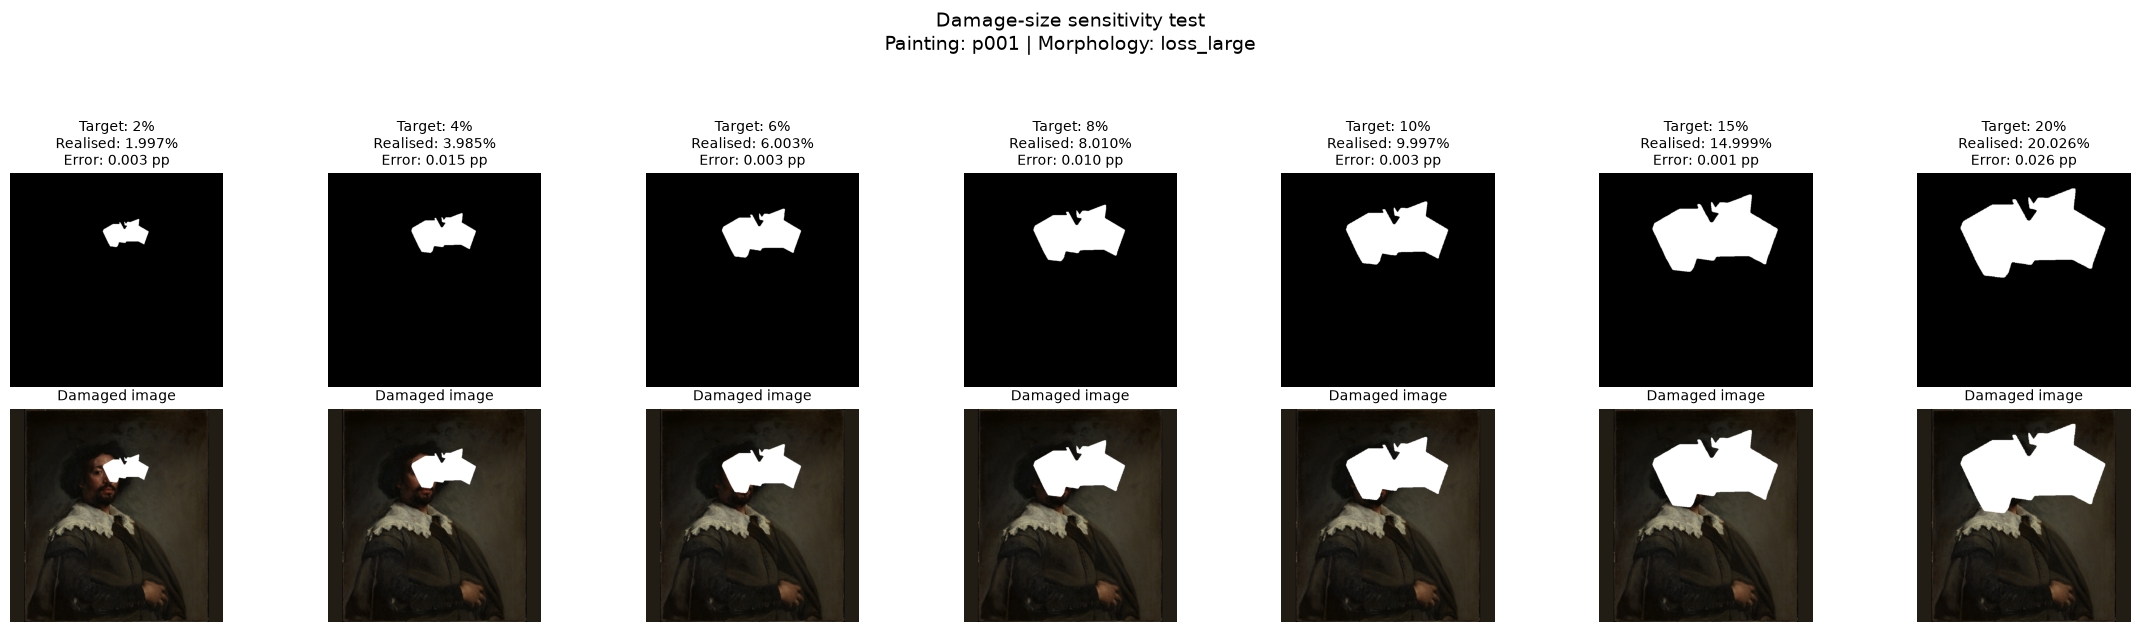

One-painting seven-level sensitivity figure saved:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\damage_size_sensitivity\figures\test_damage_size_progression_loss_large.png


In [7]:
# Visualise the one-painting, seven-level matched size progression

clean_test_row = (
    test_processed_metadata_df.iloc[0]
)

clean_test_path = Path(
    clean_test_row[
        clean_path_column
    ]
)

if not clean_test_path.is_absolute():
    clean_test_path = (
        PROJECT_ROOT
        / clean_test_path
    )

if not clean_test_path.exists():
    raise FileNotFoundError(
        "Clean test image not found: "
        f"{clean_test_path}"
    )

with Image.open(
    clean_test_path
) as clean_test_image:
    clean_test_rgb = (
        clean_test_image
        .convert("RGB")
    )

base_mask_type = (
    base_mask_types[0]
)

progression_rows_df = (
    test_sensitivity_metadata_df[
        test_sensitivity_metadata_df[
            "base_mask_type"
        ]
        == base_mask_type
    ]
    .sort_values(
        "target_percentage_content",
        kind="stable",
    )
    .reset_index(drop=True)
)

if len(
    progression_rows_df
) != expected_test_case_count:
    raise ValueError(
        "Progression visualisation requires exactly "
        f"{expected_test_case_count} cases: "
        f"observed={len(progression_rows_df)}"
    )

observed_progression_targets = tuple(
    progression_rows_df[
        "target_percentage_content"
    ]
    .astype(float)
    .tolist()
)

if observed_progression_targets != target_percentages:
    raise ValueError(
        "Progression rows do not match the expected "
        "target-percentage order: "
        f"observed={observed_progression_targets}, "
        f"expected={target_percentages}"
    )

figure, axes = plt.subplots(
    2,
    expected_test_case_count,
    figsize=(
        3.2 * expected_test_case_count,
        6.4,
    ),
    squeeze=False,
)

for column_index, case_row in (
    progression_rows_df.iterrows()
):
    generated_mask_path = Path(
        case_row[
            "sensitivity_mask_path"
        ]
    )

    generated_damaged_path = Path(
        case_row[
            "damaged_path"
        ]
    )

    if not generated_mask_path.is_absolute():
        generated_mask_path = (
            PROJECT_ROOT
            / generated_mask_path
        )

    if not generated_damaged_path.is_absolute():
        generated_damaged_path = (
            PROJECT_ROOT
            / generated_damaged_path
        )

    if not generated_mask_path.exists():
        raise FileNotFoundError(
            "Generated sensitivity mask not found: "
            f"{generated_mask_path}"
        )

    if not generated_damaged_path.exists():
        raise FileNotFoundError(
            "Generated damaged image not found: "
            f"{generated_damaged_path}"
        )

    with Image.open(
        generated_mask_path
    ) as generated_mask_image:
        mask_display = (
            generated_mask_image
            .convert("L")
            .copy()
        )

    with Image.open(
        generated_damaged_path
    ) as generated_damaged_image:
        damaged_display = (
            generated_damaged_image
            .convert("RGB")
            .copy()
        )

    target_percentage = float(
        case_row[
            "target_percentage_content"
        ]
    )

    realised_percentage = float(
        case_row[
            "realised_percentage_content"
        ]
    )

    absolute_error = float(
        case_row[
            "absolute_percentage_error_content"
        ]
    )

    axes[
        0,
        column_index,
    ].imshow(
        mask_display,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        0,
        column_index,
    ].set_title(
        (
            f"Target: {target_percentage:.0f}%\n"
            f"Realised: {realised_percentage:.3f}%\n"
            f"Error: {absolute_error:.3f} pp"
        ),
        fontsize=10,
    )

    axes[
        0,
        column_index,
    ].axis("off")

    axes[
        1,
        column_index,
    ].imshow(
        damaged_display
    )

    axes[
        1,
        column_index,
    ].set_title(
        "Damaged image",
        fontsize=10,
    )

    axes[
        1,
        column_index,
    ].axis("off")

axes[
    0,
    0,
].set_ylabel(
    "Generated masks",
    fontsize=11,
)

axes[
    1,
    0,
].set_ylabel(
    "Damaged images",
    fontsize=11,
)

figure.suptitle(
    (
        "Damage-size sensitivity test\n"
        f"Painting: {test_painting_id} | "
        f"Morphology: {base_mask_type}"
    ),
    fontsize=14,
)

figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.92,
    ]
)

test_figure_path = (
    figures_dir
    / (
        "test_damage_size_progression_"
        f"{base_mask_type}.png"
    )
)

figure.savefig(
    test_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(
    figure
)

if not test_figure_path.exists():
    raise FileNotFoundError(
        "Test sensitivity figure was not saved: "
        f"{test_figure_path}"
    )

if test_figure_path.stat().st_size <= 0:
    raise ValueError(
        "Saved test sensitivity figure is empty: "
        f"{test_figure_path}"
    )

print(
    "One-painting seven-level sensitivity "
    "figure saved:"
)

print(
    test_figure_path
)

In [9]:
# Generate the full canonical 35-case damage-size sensitivity dataset

expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

expected_mask_filenames = {
    f"{case_id}_mask.png"
    for case_id in expected_case_ids
}

expected_damaged_filenames = {
    f"{case_id}_damaged.png"
    for case_id in expected_case_ids
}

sensitivity_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

sensitivity_damaged_dir.mkdir(
    parents=True,
    exist_ok=True,
)

existing_mask_files = [
    path
    for path in sensitivity_mask_dir.glob(
        "*_mask.png"
    )
    if path.is_file()
]

existing_damaged_files = [
    path
    for path in sensitivity_damaged_dir.glob(
        "*_damaged.png"
    )
    if path.is_file()
]

stale_mask_files = [
    path
    for path in existing_mask_files
    if path.name
    not in expected_mask_filenames
]

stale_damaged_files = [
    path
    for path in existing_damaged_files
    if path.name
    not in expected_damaged_filenames
]

stale_file_records = []

for stale_path in stale_mask_files:
    stale_file_records.append(
        {
            "file_type": (
                "sensitivity_mask"
            ),
            "filename": stale_path.name,
            "path": str(
                stale_path
            ),
        }
    )

for stale_path in stale_damaged_files:
    stale_file_records.append(
        {
            "file_type": (
                "damaged_image"
            ),
            "filename": stale_path.name,
            "path": str(
                stale_path
            ),
        }
    )

stale_files_df = pd.DataFrame(
    stale_file_records
)

if not stale_files_df.empty:
    print(
        "Removing stale sensitivity files:"
    )

    display(
        stale_files_df
    )

for stale_path in (
    stale_mask_files
    + stale_damaged_files
):
    stale_path.unlink()

print(
    "Stale mask files removed:",
    len(
        stale_mask_files
    ),
)

print(
    "Stale damaged files removed:",
    len(
        stale_damaged_files
    ),
)

generation_started_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)

sensitivity_metadata_df = (
    create_damage_size_sensitivity_dataset(
        processed_metadata=(
            sensitivity_processed_metadata_df
        ),
        mask_metadata=(
            selected_base_mask_metadata_df
        ),
        target_percentages=(
            target_percentages
        ),
        output_mask_dir=(
            sensitivity_mask_dir
        ),
        output_damaged_dir=(
            sensitivity_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        base_mask_types=(
            base_mask_types
        ),
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

generation_completed_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)

print(
    "Generation started:",
    generation_started_at_utc,
)

print(
    "Generation completed:",
    generation_completed_at_utc,
)

print(
    "Generated rows:",
    len(
        sensitivity_metadata_df
    ),
)

if sensitivity_metadata_df.empty:
    raise ValueError(
        "Full sensitivity generation returned "
        "an empty metadata table."
    )

if (
    "status"
    not in sensitivity_metadata_df.columns
):
    raise ValueError(
        "Full sensitivity generation did not "
        "return a status column."
    )

generation_status_summary_df = (
    sensitivity_metadata_df[
        "status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "status"
    )
    .reset_index(
        name="case_count"
    )
)

display(
    generation_status_summary_df
)

generation_error_rows_df = (
    sensitivity_metadata_df[
        sensitivity_metadata_df[
            "status"
        ]
        != "ok"
    ]
)

if not generation_error_rows_df.empty:
    print(
        "Generation error rows:"
    )

    display(
        generation_error_rows_df
    )

    raise ValueError(
        "Full sensitivity generation produced "
        "one or more error rows."
    )

if len(
    sensitivity_metadata_df
) != expected_case_count:
    raise ValueError(
        "Full sensitivity generation row count "
        "is invalid: "
        f"observed={len(sensitivity_metadata_df)}, "
        f"expected={expected_case_count}"
    )

duplicate_case_rows_df = (
    sensitivity_metadata_df[
        sensitivity_metadata_df[
            "case_id"
        ]
        .astype(str)
        .duplicated(
            keep=False
        )
    ]
)

if not duplicate_case_rows_df.empty:
    display(
        duplicate_case_rows_df
    )

    raise ValueError(
        "Full sensitivity generation contains "
        "duplicate case IDs."
    )

observed_case_ids = set(
    sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

missing_generated_case_ids = sorted(
    expected_case_ids
    - observed_case_ids
)

unexpected_generated_case_ids = sorted(
    observed_case_ids
    - expected_case_ids
)

if missing_generated_case_ids:
    print(
        "Missing generated cases:"
    )

    display(
        pd.DataFrame(
            {
                "missing_case_id": (
                    missing_generated_case_ids
                )
            }
        )
    )

if unexpected_generated_case_ids:
    print(
        "Unexpected generated cases:"
    )

    display(
        pd.DataFrame(
            {
                "unexpected_case_id": (
                    unexpected_generated_case_ids
                )
            }
        )
    )

if (
    missing_generated_case_ids
    or unexpected_generated_case_ids
):
    raise ValueError(
        "Generated sensitivity case inventory "
        "does not match the expected manifest."
    )

selected_painting_id_set = set(
    sensitivity_processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .tolist()
)

generated_painting_id_set = set(
    sensitivity_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .tolist()
)

if (
    generated_painting_id_set
    != selected_painting_id_set
):
    raise ValueError(
        "Generated painting inventory does not "
        "match the selected five-painting subset: "
        f"generated={sorted(generated_painting_id_set)}, "
        f"selected={sorted(selected_painting_id_set)}"
    )

if not (
    sensitivity_metadata_df[
        "base_mask_type"
    ]
    .astype(str)
    == "loss_large"
).all():
    raise ValueError(
        "Generated sensitivity metadata contains "
        "a mask type other than loss_large."
    )

generated_distribution_df = (
    sensitivity_metadata_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

invalid_generated_distribution_df = (
    generated_distribution_df[
        (
            generated_distribution_df[
                "case_count"
            ]
            != expected_painting_count
        )
        |
        (
            generated_distribution_df[
                "painting_count"
            ]
            != expected_painting_count
        )
    ]
)

print(
    "Generated case distribution:"
)

display(
    generated_distribution_df
)

if len(
    generated_distribution_df
) != expected_target_level_count:
    raise ValueError(
        "Generated sensitivity distribution does "
        "not contain the expected number of "
        "target levels: "
        f"observed={len(generated_distribution_df)}, "
        f"expected={expected_target_level_count}"
    )

if not invalid_generated_distribution_df.empty:
    display(
        invalid_generated_distribution_df
    )

    raise ValueError(
        "Generated sensitivity distribution is "
        "incomplete."
    )

required_provenance_columns = {
    "deterministic_seed",
    "global_seed",
    "generator_name",
    "generator_version",
    "generated_at_utc",
    "clean_sha256",
    "base_mask_sha256",
    "sensitivity_mask_sha256",
    "damaged_sha256",
}

missing_provenance_columns = sorted(
    required_provenance_columns
    - set(
        sensitivity_metadata_df.columns
    )
)

if missing_provenance_columns:
    raise ValueError(
        "Sensitivity metadata is missing "
        "provenance columns: "
        f"{missing_provenance_columns}"
    )

missing_provenance_values_df = (
    sensitivity_metadata_df[
        sorted(
            required_provenance_columns
        )
    ]
    .isna()
    .sum()
    .rename(
        "missing_count"
    )
    .reset_index()
    .rename(
        columns={
            "index": "column",
        }
    )
)

display(
    missing_provenance_values_df
)

if (
    missing_provenance_values_df[
        "missing_count"
    ]
    > 0
).any():
    raise ValueError(
        "Sensitivity metadata contains missing "
        "provenance values."
    )

if not (
    sensitivity_metadata_df[
        "global_seed"
    ]
    .astype(int)
    == global_seed
).all():
    raise ValueError(
        "Generated metadata contains an unexpected "
        "global seed."
    )

if not (
    sensitivity_metadata_df[
        "generator_name"
    ]
    .astype(str)
    == GENERATOR_NAME
).all():
    raise ValueError(
        "Generated metadata contains an unexpected "
        "generator name."
    )

if not (
    sensitivity_metadata_df[
        "generator_version"
    ]
    .astype(str)
    == GENERATOR_VERSION
).all():
    raise ValueError(
        "Generated metadata contains an unexpected "
        "generator version."
    )

actual_mask_filenames = {
    path.name
    for path in sensitivity_mask_dir.glob(
        "*_mask.png"
    )
    if path.is_file()
}

actual_damaged_filenames = {
    path.name
    for path in sensitivity_damaged_dir.glob(
        "*_damaged.png"
    )
    if path.is_file()
}

missing_mask_filenames = sorted(
    expected_mask_filenames
    - actual_mask_filenames
)

unexpected_mask_filenames = sorted(
    actual_mask_filenames
    - expected_mask_filenames
)

missing_damaged_filenames = sorted(
    expected_damaged_filenames
    - actual_damaged_filenames
)

unexpected_damaged_filenames = sorted(
    actual_damaged_filenames
    - expected_damaged_filenames
)

generated_file_summary_df = pd.DataFrame(
    [
        {
            "check": "metadata_rows",
            "observed": len(
                sensitivity_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    sensitivity_metadata_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "mask_files",
            "observed": len(
                actual_mask_filenames
            ),
            "expected": expected_case_count,
            "passed": (
                actual_mask_filenames
                == expected_mask_filenames
            ),
        },
        {
            "check": "damaged_files",
            "observed": len(
                actual_damaged_filenames
            ),
            "expected": expected_case_count,
            "passed": (
                actual_damaged_filenames
                == expected_damaged_filenames
            ),
        },
        {
            "check": "missing_mask_files",
            "observed": len(
                missing_mask_filenames
            ),
            "expected": 0,
            "passed": (
                len(
                    missing_mask_filenames
                )
                == 0
            ),
        },
        {
            "check": "unexpected_mask_files",
            "observed": len(
                unexpected_mask_filenames
            ),
            "expected": 0,
            "passed": (
                len(
                    unexpected_mask_filenames
                )
                == 0
            ),
        },
        {
            "check": "missing_damaged_files",
            "observed": len(
                missing_damaged_filenames
            ),
            "expected": 0,
            "passed": (
                len(
                    missing_damaged_filenames
                )
                == 0
            ),
        },
        {
            "check": "unexpected_damaged_files",
            "observed": len(
                unexpected_damaged_filenames
            ),
            "expected": 0,
            "passed": (
                len(
                    unexpected_damaged_filenames
                )
                == 0
            ),
        },
    ]
)

print(
    "Generated file summary:"
)

display(
    generated_file_summary_df
)

if not generated_file_summary_df[
    "passed"
].all():
    raise ValueError(
        "Generated sensitivity file inventory "
        "is invalid."
    )

print(
    "\nFull canonical 35-case sensitivity "
    "generation passed."
)

Stale mask files removed: 0
Stale damaged files removed: 0
Generation started: 2026-07-23T11:01:32.570679+00:00
Generation completed: 2026-07-23T11:01:48.382369+00:00
Generated rows: 35


,status,case_count
0,ok,35


Generated case distribution:


,base_mask_type,target_percentage_content,case_count,painting_count
0,loss_large,2.0,5,5
1,loss_large,4.0,5,5
2,loss_large,6.0,5,5
3,loss_large,8.0,5,5
4,loss_large,10.0,5,5
5,loss_large,15.0,5,5
6,loss_large,20.0,5,5


,column,missing_count
0,base_mask_sha256,0
1,clean_sha256,0
2,damaged_sha256,0
3,deterministic_seed,0
4,generated_at_utc,0
5,generator_name,0
6,generator_version,0
7,global_seed,0
8,sensitivity_mask_sha256,0


Generated file summary:


,check,observed,expected,passed
0,metadata_rows,35,35,True
1,mask_files,35,35,True
2,damaged_files,35,35,True
3,missing_mask_files,0,0,True
4,unexpected_mask_files,0,0,True
5,missing_damaged_files,0,0,True
6,unexpected_damaged_files,0,0,True



Full canonical 35-case sensitivity generation passed.


In [11]:
# Validate the full canonical damage-size sensitivity dataset

sensitivity_validation_df = (
    validate_damage_size_sensitivity_dataset(
        sensitivity_metadata=(
            sensitivity_metadata_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
        maximum_percentage_error=(
            maximum_percentage_error
        ),
    )
)

if len(
    sensitivity_validation_df
) != expected_case_count:
    raise ValueError(
        "Sensitivity validation row count is invalid: "
        f"observed={len(sensitivity_validation_df)}, "
        f"expected={expected_case_count}"
    )

required_validation_columns = {
    "case_id",
    "target_error_valid",
    "outside_mask_changed_pixels",
    "outside_mask_preserved",
    "inside_mask_not_fill_pixels",
    "masked_fill_valid",
    "checksum_valid",
    "validation_passed",
}

missing_validation_columns = sorted(
    required_validation_columns
    - set(
        sensitivity_validation_df.columns
    )
)

if missing_validation_columns:
    raise ValueError(
        "Sensitivity validation output is missing "
        "required columns: "
        f"{missing_validation_columns}"
    )

duplicate_validation_case_rows_df = (
    sensitivity_validation_df[
        sensitivity_validation_df[
            "case_id"
        ]
        .astype(str)
        .duplicated(
            keep=False
        )
    ]
)

if not duplicate_validation_case_rows_df.empty:
    display(
        duplicate_validation_case_rows_df
    )

    raise ValueError(
        "Sensitivity validation output contains "
        "duplicate case IDs."
    )

metadata_case_ids = set(
    sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

validation_case_ids = set(
    sensitivity_validation_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

missing_validation_case_ids = sorted(
    metadata_case_ids
    - validation_case_ids
)

unexpected_validation_case_ids = sorted(
    validation_case_ids
    - metadata_case_ids
)

if (
    missing_validation_case_ids
    or unexpected_validation_case_ids
):
    if missing_validation_case_ids:
        display(
            pd.DataFrame(
                {
                    "missing_validation_case_id": (
                        missing_validation_case_ids
                    )
                }
            )
        )

    if unexpected_validation_case_ids:
        display(
            pd.DataFrame(
                {
                    "unexpected_validation_case_id": (
                        unexpected_validation_case_ids
                    )
                }
            )
        )

    raise ValueError(
        "Validation case inventory does not match "
        "the generated metadata."
    )

validation_summary_df = pd.DataFrame(
    [
        {
            "check": "validation_rows",
            "observed": len(
                sensitivity_validation_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    sensitivity_validation_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                sensitivity_validation_df[
                    "case_id"
                ]
                .nunique()
            ),
            "expected": expected_case_count,
            "passed": (
                sensitivity_validation_df[
                    "case_id"
                ]
                .nunique()
                == expected_case_count
            ),
        },
        {
            "check": "validation_failures",
            "observed": int(
                (
                    ~sensitivity_validation_df[
                        "validation_passed"
                    ]
                    .fillna(False)
                    .astype(bool)
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                sensitivity_validation_df[
                    "validation_passed"
                ]
                .fillna(False)
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "target_error_failures",
            "observed": int(
                (
                    ~sensitivity_validation_df[
                        "target_error_valid"
                    ]
                    .fillna(False)
                    .astype(bool)
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                sensitivity_validation_df[
                    "target_error_valid"
                ]
                .fillna(False)
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "outside_mask_changed_pixels",
            "observed": int(
                sensitivity_validation_df[
                    "outside_mask_changed_pixels"
                ]
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                sensitivity_validation_df[
                    "outside_mask_preserved"
                ]
                .fillna(False)
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "inside_mask_not_fill_pixels",
            "observed": int(
                sensitivity_validation_df[
                    "inside_mask_not_fill_pixels"
                ]
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                sensitivity_validation_df[
                    "masked_fill_valid"
                ]
                .fillna(False)
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "checksum_failures",
            "observed": int(
                (
                    ~sensitivity_validation_df[
                        "checksum_valid"
                    ]
                    .fillna(False)
                    .astype(bool)
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                sensitivity_validation_df[
                    "checksum_valid"
                ]
                .fillna(False)
                .astype(bool)
                .all()
            ),
        },
    ]
)

print(
    "Full sensitivity validation summary:"
)

display(
    validation_summary_df
)

failed_sensitivity_validation_df = (
    sensitivity_validation_df[
        ~sensitivity_validation_df[
            "validation_passed"
        ]
        .fillna(False)
        .astype(bool)
    ]
)

if not failed_sensitivity_validation_df.empty:
    print(
        "Failed sensitivity validation rows:"
    )

    display(
        failed_sensitivity_validation_df
    )

required_accuracy_columns = {
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
}

missing_accuracy_columns = sorted(
    required_accuracy_columns
    - set(
        sensitivity_metadata_df.columns
    )
)

if missing_accuracy_columns:
    raise ValueError(
        "Sensitivity metadata is missing required "
        "accuracy columns: "
        f"{missing_accuracy_columns}"
    )

target_accuracy_summary_df = (
    sensitivity_metadata_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        mean_realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        minimum_realised_percentage_content=(
            "realised_percentage_content",
            "min",
        ),
        maximum_realised_percentage_content=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)

print(
    "Target-accuracy summary:"
)

display(
    target_accuracy_summary_df
)

painting_accuracy_summary_df = (
    sensitivity_metadata_df
    .groupby(
        "painting_id",
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        target_level_count=(
            "target_percentage_content",
            "nunique",
        ),
        mean_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)

print(
    "Per-painting accuracy summary:"
)

display(
    painting_accuracy_summary_df
)

invalid_painting_summary_df = (
    painting_accuracy_summary_df[
        (
            painting_accuracy_summary_df[
                "case_count"
            ]
            != expected_target_level_count
        )
        |
        (
            painting_accuracy_summary_df[
                "target_level_count"
            ]
            != expected_target_level_count
        )
    ]
)

if not invalid_painting_summary_df.empty:
    display(
        invalid_painting_summary_df
    )

    raise ValueError(
        "One or more selected paintings do not "
        "contain all expected target levels."
    )

if not validation_summary_df[
    "passed"
].all():
    raise ValueError(
        "Full damage-size sensitivity validation "
        "failed."
    )

if (
    sensitivity_metadata_df[
        "absolute_percentage_error_content"
    ]
    .astype(float)
    > maximum_percentage_error
).any():
    excessive_error_rows_df = (
        sensitivity_metadata_df[
            sensitivity_metadata_df[
                "absolute_percentage_error_content"
            ]
            .astype(float)
            > maximum_percentage_error
        ]
    )

    display(
        excessive_error_rows_df
    )

    raise ValueError(
        "At least one generated case exceeded the "
        "configured maximum percentage error."
    )

print(
    "\nFull 35-case damage-size sensitivity "
    "validation passed."
)

Full sensitivity validation summary:


,check,observed,expected,passed
0,validation_rows,35,35,True
1,unique_case_ids,35,35,True
2,validation_failures,0,0,True
3,target_error_failures,0,0,True
4,outside_mask_changed_pixels,0,0,True
5,inside_mask_not_fill_pixels,0,0,True
6,checksum_failures,0,0,True


Target-accuracy summary:


,base_mask_type,target_percentage_content,case_count,painting_count,mean_realised_percentage_content,minimum_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content
0,loss_large,2.0,5,5,2.002274,1.997117,2.007041,0.004508,0.007041
1,loss_large,4.0,5,5,3.994237,3.984807,4.000674,0.006033,0.015193
2,loss_large,6.0,5,5,5.999438,5.984256,6.011413,0.009441,0.015744
3,loss_large,8.0,5,5,7.997367,7.986342,8.009995,0.010581,0.013658
4,loss_large,10.0,5,5,10.003581,9.990453,10.020732,0.008965,0.020732
5,loss_large,15.0,5,5,14.990585,14.978324,15.003987,0.011010,0.021676
6,loss_large,20.0,5,5,20.007014,19.986610,20.025570,0.012370,0.025570


Per-painting accuracy summary:


,painting_id,case_count,target_level_count,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content
0,p001,7,7,0.008543,0.025570
1,p018,7,7,0.011906,0.021676
2,p026,7,7,0.006740,0.013390
3,p039,7,7,0.009279,0.020732
4,p043,7,7,0.008466,0.015744



Full 35-case damage-size sensitivity validation passed.


In [12]:
# Save the canonical sensitivity metadata and experiment manifest

sensitivity_metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

sensitivity_outputs_dir.mkdir(
    parents=True,
    exist_ok=True,
)

sensitivity_metadata_to_save_df = (
    sensitivity_metadata_df
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "target_percentage_content",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

sensitivity_manifest_df = (
    expected_case_manifest_df
    .merge(
        sensitivity_metadata_to_save_df[
            [
                "case_id",
                "realised_percentage_content",
                "absolute_percentage_error_content",
                "deterministic_seed",
                "sensitivity_mask_path",
                "damaged_path",
                "sensitivity_mask_sha256",
                "damaged_sha256",
                "generator_name",
                "generator_version",
                "generated_at_utc",
                "status",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "target_percentage_content",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

if len(
    sensitivity_manifest_df
) != expected_case_count:
    raise ValueError(
        "Sensitivity manifest row count is invalid: "
        f"observed={len(sensitivity_manifest_df)}, "
        f"expected={expected_case_count}"
    )

if (
    sensitivity_manifest_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Sensitivity manifest contains duplicate "
        "case IDs."
    )

manifest_required_columns = {
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "deterministic_seed",
    "sensitivity_mask_path",
    "damaged_path",
    "sensitivity_mask_sha256",
    "damaged_sha256",
    "generator_name",
    "generator_version",
    "generated_at_utc",
    "status",
}

missing_manifest_columns = sorted(
    manifest_required_columns
    - set(
        sensitivity_manifest_df.columns
    )
)

if missing_manifest_columns:
    raise ValueError(
        "Sensitivity manifest is missing required "
        "columns: "
        f"{missing_manifest_columns}"
    )

missing_manifest_values_df = (
    sensitivity_manifest_df[
        sorted(
            manifest_required_columns
        )
    ]
    .isna()
    .sum()
    .rename(
        "missing_count"
    )
    .reset_index()
    .rename(
        columns={
            "index": "column",
        }
    )
)

display(
    missing_manifest_values_df
)

if (
    missing_manifest_values_df[
        "missing_count"
    ]
    > 0
).any():
    raise ValueError(
        "Sensitivity manifest contains missing "
        "required values."
    )

sensitivity_manifest_path = (
    sensitivity_outputs_dir
    / "damage_size_sensitivity_manifest.csv"
)

sensitivity_validation_path = (
    sensitivity_outputs_dir
    / "damage_size_sensitivity_validation.csv"
)

sensitivity_metadata_to_save_df.to_csv(
    sensitivity_metadata_path,
    index=False,
)

sensitivity_manifest_df.to_csv(
    sensitivity_manifest_path,
    index=False,
)

sensitivity_validation_df.to_csv(
    sensitivity_validation_path,
    index=False,
)

saved_table_summary_df = pd.DataFrame(
    [
        {
            "table": "canonical_metadata",
            "path": str(
                sensitivity_metadata_path
            ),
            "row_count": len(
                sensitivity_metadata_to_save_df
            ),
            "expected_rows": expected_case_count,
            "file_exists": (
                sensitivity_metadata_path.exists()
            ),
            "file_size_bytes": (
                sensitivity_metadata_path.stat().st_size
                if sensitivity_metadata_path.exists()
                else 0
            ),
        },
        {
            "table": "experiment_manifest",
            "path": str(
                sensitivity_manifest_path
            ),
            "row_count": len(
                sensitivity_manifest_df
            ),
            "expected_rows": expected_case_count,
            "file_exists": (
                sensitivity_manifest_path.exists()
            ),
            "file_size_bytes": (
                sensitivity_manifest_path.stat().st_size
                if sensitivity_manifest_path.exists()
                else 0
            ),
        },
        {
            "table": "validation_results",
            "path": str(
                sensitivity_validation_path
            ),
            "row_count": len(
                sensitivity_validation_df
            ),
            "expected_rows": expected_case_count,
            "file_exists": (
                sensitivity_validation_path.exists()
            ),
            "file_size_bytes": (
                sensitivity_validation_path.stat().st_size
                if sensitivity_validation_path.exists()
                else 0
            ),
        },
    ]
)

saved_table_summary_df[
    "passed"
] = (
    saved_table_summary_df[
        "file_exists"
    ]
    & (
        saved_table_summary_df[
            "file_size_bytes"
        ]
        > 0
    )
    & (
        saved_table_summary_df[
            "row_count"
        ]
        == saved_table_summary_df[
            "expected_rows"
        ]
    )
)

display(
    saved_table_summary_df
)

if not saved_table_summary_df[
    "passed"
].all():
    raise ValueError(
        "One or more canonical sensitivity tables "
        "were not saved correctly."
    )

print(
    "\nCanonical sensitivity metadata, manifest, "
    "and validation tables saved."
)

,column,missing_count
0,absolute_percentage_error_content,0
1,base_mask_type,0
2,case_id,0
3,damaged_path,0
4,damaged_sha256,0
5,deterministic_seed,0
6,generated_at_utc,0
7,generator_name,0
8,generator_version,0
9,painting_id,0


,table,path,row_count,expected_rows,file_exists,file_size_bytes,passed
0,canonical_metadata,D:\Masters\FH\Thesis\painting-restoration-eval...,35,35,True,39409,True
1,experiment_manifest,D:\Masters\FH\Thesis\painting-restoration-eval...,35,35,True,18642,True
2,validation_results,D:\Masters\FH\Thesis\painting-restoration-eval...,35,35,True,7119,True



Canonical sensitivity metadata, manifest, and validation tables saved.


In [13]:
# Reload and audit the canonical sensitivity artefacts

reloaded_sensitivity_metadata_df = pd.read_csv(
    sensitivity_metadata_path
)

reloaded_sensitivity_manifest_df = pd.read_csv(
    sensitivity_manifest_path
)

reloaded_sensitivity_validation_df = pd.read_csv(
    sensitivity_validation_path
)

expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

metadata_case_ids = set(
    reloaded_sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

manifest_case_ids = set(
    reloaded_sensitivity_manifest_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

validation_case_ids = set(
    reloaded_sensitivity_validation_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

expected_mask_filenames = {
    f"{case_id}_mask.png"
    for case_id in expected_case_ids
}

expected_damaged_filenames = {
    f"{case_id}_damaged.png"
    for case_id in expected_case_ids
}

observed_mask_filenames = {
    path.name
    for path in sensitivity_mask_dir.glob(
        "*.png"
    )
    if path.is_file()
}

observed_damaged_filenames = {
    path.name
    for path in sensitivity_damaged_dir.glob(
        "*.png"
    )
    if path.is_file()
}

missing_metadata_case_ids = sorted(
    expected_case_ids
    - metadata_case_ids
)

unexpected_metadata_case_ids = sorted(
    metadata_case_ids
    - expected_case_ids
)

missing_manifest_case_ids = sorted(
    expected_case_ids
    - manifest_case_ids
)

unexpected_manifest_case_ids = sorted(
    manifest_case_ids
    - expected_case_ids
)

missing_validation_case_ids = sorted(
    expected_case_ids
    - validation_case_ids
)

unexpected_validation_case_ids = sorted(
    validation_case_ids
    - expected_case_ids
)

missing_mask_filenames = sorted(
    expected_mask_filenames
    - observed_mask_filenames
)

orphan_mask_filenames = sorted(
    observed_mask_filenames
    - expected_mask_filenames
)

missing_damaged_filenames = sorted(
    expected_damaged_filenames
    - observed_damaged_filenames
)

orphan_damaged_filenames = sorted(
    observed_damaged_filenames
    - expected_damaged_filenames
)

final_inventory_audit_df = pd.DataFrame(
    [
        {
            "check": "metadata_rows",
            "observed": len(
                reloaded_sensitivity_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    reloaded_sensitivity_metadata_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "manifest_rows",
            "observed": len(
                reloaded_sensitivity_manifest_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    reloaded_sensitivity_manifest_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "validation_rows",
            "observed": len(
                reloaded_sensitivity_validation_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    reloaded_sensitivity_validation_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "metadata_case_inventory_errors",
            "observed": (
                len(
                    missing_metadata_case_ids
                )
                + len(
                    unexpected_metadata_case_ids
                )
            ),
            "expected": 0,
            "passed": (
                not missing_metadata_case_ids
                and not unexpected_metadata_case_ids
            ),
        },
        {
            "check": "manifest_case_inventory_errors",
            "observed": (
                len(
                    missing_manifest_case_ids
                )
                + len(
                    unexpected_manifest_case_ids
                )
            ),
            "expected": 0,
            "passed": (
                not missing_manifest_case_ids
                and not unexpected_manifest_case_ids
            ),
        },
        {
            "check": "validation_case_inventory_errors",
            "observed": (
                len(
                    missing_validation_case_ids
                )
                + len(
                    unexpected_validation_case_ids
                )
            ),
            "expected": 0,
            "passed": (
                not missing_validation_case_ids
                and not unexpected_validation_case_ids
            ),
        },
        {
            "check": "mask_files",
            "observed": len(
                observed_mask_filenames
            ),
            "expected": expected_case_count,
            "passed": (
                observed_mask_filenames
                == expected_mask_filenames
            ),
        },
        {
            "check": "damaged_files",
            "observed": len(
                observed_damaged_filenames
            ),
            "expected": expected_case_count,
            "passed": (
                observed_damaged_filenames
                == expected_damaged_filenames
            ),
        },
        {
            "check": "missing_mask_files",
            "observed": len(
                missing_mask_filenames
            ),
            "expected": 0,
            "passed": (
                not missing_mask_filenames
            ),
        },
        {
            "check": "orphan_mask_files",
            "observed": len(
                orphan_mask_filenames
            ),
            "expected": 0,
            "passed": (
                not orphan_mask_filenames
            ),
        },
        {
            "check": "missing_damaged_files",
            "observed": len(
                missing_damaged_filenames
            ),
            "expected": 0,
            "passed": (
                not missing_damaged_filenames
            ),
        },
        {
            "check": "orphan_damaged_files",
            "observed": len(
                orphan_damaged_filenames
            ),
            "expected": 0,
            "passed": (
                not orphan_damaged_filenames
            ),
        },
    ]
)

print(
    "Final sensitivity inventory audit:"
)

display(
    final_inventory_audit_df
)

audit_problem_tables = {
    "missing_metadata_case_id": (
        missing_metadata_case_ids
    ),
    "unexpected_metadata_case_id": (
        unexpected_metadata_case_ids
    ),
    "missing_manifest_case_id": (
        missing_manifest_case_ids
    ),
    "unexpected_manifest_case_id": (
        unexpected_manifest_case_ids
    ),
    "missing_validation_case_id": (
        missing_validation_case_ids
    ),
    "unexpected_validation_case_id": (
        unexpected_validation_case_ids
    ),
    "missing_mask_filename": (
        missing_mask_filenames
    ),
    "orphan_mask_filename": (
        orphan_mask_filenames
    ),
    "missing_damaged_filename": (
        missing_damaged_filenames
    ),
    "orphan_damaged_filename": (
        orphan_damaged_filenames
    ),
}

for column_name, values in (
    audit_problem_tables.items()
):
    if values:
        display(
            pd.DataFrame(
                {
                    column_name: values,
                }
            )
        )

if not final_inventory_audit_df[
    "passed"
].all():
    raise ValueError(
        "Final sensitivity artefact inventory "
        "audit failed."
    )

print(
    "\nCanonical 35-case sensitivity artefact "
    "inventory passed."
)

Final sensitivity inventory audit:


,check,observed,expected,passed
0,metadata_rows,35,35,True
1,manifest_rows,35,35,True
2,validation_rows,35,35,True
3,metadata_case_inventory_errors,0,0,True
4,manifest_case_inventory_errors,0,0,True
5,validation_case_inventory_errors,0,0,True
6,mask_files,35,35,True
7,damaged_files,35,35,True
8,missing_mask_files,0,0,True
9,orphan_mask_files,0,0,True



Canonical 35-case sensitivity artefact inventory passed.


In [16]:
# Create and save compact damage-size sensitivity summaries

sensitivity_summary_dir = (
    sensitivity_outputs_dir
    / "summaries"
)

sensitivity_summary_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Use the canonical metadata dataframe saved in Cell 9.
summary_source_df = (
    sensitivity_metadata_to_save_df
    .copy()
)

required_summary_columns = {
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "generator_name",
    "generator_version",
}

missing_summary_columns = sorted(
    required_summary_columns
    - set(summary_source_df.columns)
)

if missing_summary_columns:
    raise ValueError(
        "Sensitivity metadata is missing columns "
        "required for summary generation: "
        f"{missing_summary_columns}"
    )

if len(summary_source_df) != expected_case_count:
    raise ValueError(
        "Summary source row count is invalid: "
        f"observed={len(summary_source_df)}, "
        f"expected={expected_case_count}"
    )

if summary_source_df["case_id"].duplicated().any():
    duplicate_case_rows_df = (
        summary_source_df[
            summary_source_df[
                "case_id"
            ].duplicated(keep=False)
        ]
        .sort_values(
            "case_id",
            kind="stable",
        )
    )

    display(
        duplicate_case_rows_df
    )

    raise ValueError(
        "Summary source contains duplicate case IDs."
    )

numeric_summary_columns = [
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
]

for column_name in numeric_summary_columns:
    summary_source_df[column_name] = pd.to_numeric(
        summary_source_df[column_name],
        errors="raise",
    )

generator_names = (
    summary_source_df[
        "generator_name"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

generator_versions = (
    summary_source_df[
        "generator_version"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(generator_names) != 1:
    raise ValueError(
        "Expected exactly one generator name, "
        f"observed={generator_names}"
    )

if len(generator_versions) != 1:
    raise ValueError(
        "Expected exactly one generator version, "
        f"observed={generator_versions}"
    )

expected_target_percentages = sorted(
    float(value)
    for value in target_percentages
)

observed_target_percentages = sorted(
    summary_source_df[
        "target_percentage_content"
    ]
    .unique()
    .tolist()
)

if observed_target_percentages != (
    expected_target_percentages
):
    raise ValueError(
        "Observed target percentages do not match "
        "the configured target levels: "
        f"observed={observed_target_percentages}, "
        f"expected={expected_target_percentages}"
    )

overall_sensitivity_summary_df = pd.DataFrame(
    [
        {
            "painting_count": (
                summary_source_df[
                    "painting_id"
                ].nunique()
            ),
            "base_mask_type_count": (
                summary_source_df[
                    "base_mask_type"
                ].nunique()
            ),
            "target_level_count": (
                summary_source_df[
                    "target_percentage_content"
                ].nunique()
            ),
            "case_count": len(
                summary_source_df
            ),
            "minimum_target_percentage_content": (
                summary_source_df[
                    "target_percentage_content"
                ].min()
            ),
            "maximum_target_percentage_content": (
                summary_source_df[
                    "target_percentage_content"
                ].max()
            ),
            "minimum_realised_percentage_content": (
                summary_source_df[
                    "realised_percentage_content"
                ].min()
            ),
            "maximum_realised_percentage_content": (
                summary_source_df[
                    "realised_percentage_content"
                ].max()
            ),
            "mean_absolute_percentage_error_content": (
                summary_source_df[
                    "absolute_percentage_error_content"
                ].mean()
            ),
            "maximum_absolute_percentage_error_content": (
                summary_source_df[
                    "absolute_percentage_error_content"
                ].max()
            ),
            "maximum_allowed_percentage_error": (
                maximum_percentage_error
            ),
            "global_seed": int(
                global_seed
            ),
            "fill_strategy": "constant_rgb",
            "generator_name": generator_names[0],
            "generator_version": (
                generator_versions[0]
            ),
        }
    ]
)

target_level_summary_df = (
    summary_source_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        mean_realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        standard_deviation_realised_percentage_content=(
            "realised_percentage_content",
            "std",
        ),
        minimum_realised_percentage_content=(
            "realised_percentage_content",
            "min",
        ),
        maximum_realised_percentage_content=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)

painting_level_summary_df = (
    summary_source_df
    .groupby(
        "painting_id",
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        target_level_count=(
            "target_percentage_content",
            "nunique",
        ),
        minimum_realised_percentage_content=(
            "realised_percentage_content",
            "min",
        ),
        maximum_realised_percentage_content=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)

invalid_target_level_summary_df = (
    target_level_summary_df[
        (
            target_level_summary_df[
                "case_count"
            ]
            != expected_painting_count
        )
        |
        (
            target_level_summary_df[
                "painting_count"
            ]
            != expected_painting_count
        )
    ]
)

if not invalid_target_level_summary_df.empty:
    display(
        invalid_target_level_summary_df
    )

    raise ValueError(
        "One or more target levels do not contain "
        "the expected five matched paintings."
    )

invalid_painting_level_summary_df = (
    painting_level_summary_df[
        (
            painting_level_summary_df[
                "case_count"
            ]
            != expected_target_level_count
        )
        |
        (
            painting_level_summary_df[
                "target_level_count"
            ]
            != expected_target_level_count
        )
    ]
)

if not invalid_painting_level_summary_df.empty:
    display(
        invalid_painting_level_summary_df
    )

    raise ValueError(
        "One or more paintings do not contain all "
        "configured damage-size levels."
    )

if (
    overall_sensitivity_summary_df.loc[
        0,
        "painting_count",
    ]
    != expected_painting_count
):
    raise ValueError(
        "Overall summary painting count is invalid."
    )

if (
    overall_sensitivity_summary_df.loc[
        0,
        "base_mask_type_count",
    ]
    != expected_base_mask_type_count
):
    raise ValueError(
        "Overall summary mask-type count is invalid."
    )

if (
    overall_sensitivity_summary_df.loc[
        0,
        "target_level_count",
    ]
    != expected_target_level_count
):
    raise ValueError(
        "Overall summary target-level count is invalid."
    )

if (
    overall_sensitivity_summary_df.loc[
        0,
        "case_count",
    ]
    != expected_case_count
):
    raise ValueError(
        "Overall summary case count is invalid."
    )

if (
    overall_sensitivity_summary_df.loc[
        0,
        "maximum_absolute_percentage_error_content",
    ]
    > maximum_percentage_error
):
    raise ValueError(
        "The maximum realised percentage error "
        "exceeds the configured tolerance."
    )

overall_summary_path = (
    sensitivity_summary_dir
    / "overall_summary.csv"
)

target_level_summary_path = (
    sensitivity_summary_dir
    / "target_level_summary.csv"
)

painting_level_summary_path = (
    sensitivity_summary_dir
    / "painting_level_summary.csv"
)

overall_sensitivity_summary_df.to_csv(
    overall_summary_path,
    index=False,
)

target_level_summary_df.to_csv(
    target_level_summary_path,
    index=False,
)

painting_level_summary_df.to_csv(
    painting_level_summary_path,
    index=False,
)

summary_file_audit_df = pd.DataFrame(
    [
        {
            "summary": "overall",
            "path": str(
                overall_summary_path
            ),
            "row_count": len(
                overall_sensitivity_summary_df
            ),
            "expected_rows": 1,
        },
        {
            "summary": "target_level",
            "path": str(
                target_level_summary_path
            ),
            "row_count": len(
                target_level_summary_df
            ),
            "expected_rows": (
                expected_target_level_count
            ),
        },
        {
            "summary": "painting_level",
            "path": str(
                painting_level_summary_path
            ),
            "row_count": len(
                painting_level_summary_df
            ),
            "expected_rows": (
                expected_painting_count
            ),
        },
    ]
)

summary_file_audit_df[
    "file_exists"
] = summary_file_audit_df[
    "path"
].map(
    lambda value: Path(value).exists()
)

summary_file_audit_df[
    "file_size_bytes"
] = summary_file_audit_df[
    "path"
].map(
    lambda value: (
        Path(value).stat().st_size
        if Path(value).exists()
        else 0
    )
)

summary_file_audit_df[
    "passed"
] = (
    summary_file_audit_df[
        "file_exists"
    ]
    & (
        summary_file_audit_df[
            "file_size_bytes"
        ]
        > 0
    )
    & (
        summary_file_audit_df[
            "row_count"
        ]
        == summary_file_audit_df[
            "expected_rows"
        ]
    )
)

print(
    "Overall sensitivity summary:"
)

display(
    overall_sensitivity_summary_df
)

print(
    "Target-level summary:"
)

display(
    target_level_summary_df
)

print(
    "Painting-level summary:"
)

display(
    painting_level_summary_df
)

print(
    "Summary file audit:"
)

display(
    summary_file_audit_df
)

if not summary_file_audit_df[
    "passed"
].all():
    raise ValueError(
        "One or more sensitivity summary files "
        "were not saved correctly."
    )

print(
    "\nCompact damage-size sensitivity summaries "
    "saved successfully."
)

Overall sensitivity summary:


,painting_count,base_mask_type_count,target_level_count,case_count,minimum_target_percentage_content,maximum_target_percentage_content,minimum_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content,maximum_allowed_percentage_error,global_seed,fill_strategy,generator_name,generator_version
0,5,1,7,35,2.0,20.0,1.997117,20.02557,0.008987,0.02557,0.5,20260505,constant_rgb,damage_size_sensitivity,1.1.0


Target-level summary:


,base_mask_type,target_percentage_content,case_count,painting_count,mean_realised_percentage_content,standard_deviation_realised_percentage_content,minimum_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content
0,loss_large,2.0,5,5,2.002274,0.004710,1.997117,2.007041,0.004508,0.007041
1,loss_large,4.0,5,5,3.994237,0.007035,3.984807,4.000674,0.006033,0.015193
2,loss_large,6.0,5,5,5.999438,0.011560,5.984256,6.011413,0.009441,0.015744
3,loss_large,8.0,5,5,7.997367,0.011855,7.986342,8.009995,0.010581,0.013658
4,loss_large,10.0,5,5,10.003581,0.012025,9.990453,10.020732,0.008965,0.020732
5,loss_large,15.0,5,5,14.990585,0.010638,14.978324,15.003987,0.011010,0.021676
6,loss_large,20.0,5,5,20.007014,0.014645,19.986610,20.025570,0.012370,0.025570


Painting-level summary:


,painting_id,case_count,target_level_count,minimum_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content
0,p001,7,7,1.997117,20.025570,0.008543,0.025570
1,p018,7,7,1.997298,20.015615,0.011906,0.021676
2,p026,7,7,2.005307,19.986610,0.006740,0.013390
3,p039,7,7,2.004608,20.003140,0.009279,0.020732
4,p043,7,7,2.007041,20.004134,0.008466,0.015744


Summary file audit:


,summary,path,row_count,expected_rows,file_exists,file_size_bytes,passed
0,overall,D:\Masters\FH\Thesis\painting-restoration-eval...,1,1,True,534,True
1,target_level,D:\Masters\FH\Thesis\painting-restoration-eval...,7,7,True,1272,True
2,painting_level,D:\Masters\FH\Thesis\painting-restoration-eval...,5,5,True,634,True



Compact damage-size sensitivity summaries saved successfully.


In [17]:
# Generate one matched damage progression figure per painting

sensitivity_figure_dir = (
    sensitivity_outputs_dir
    / "figures"
    / "damage_progressions"
)

sensitivity_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for stale_figure_path in (
    sensitivity_figure_dir.glob(
        "*.png"
    )
):
    stale_figure_path.unlink()

ordered_progression_df = (
    sensitivity_metadata_to_save_df
    .sort_values(
        [
            "painting_id",
            "target_percentage_content",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

generated_figure_records = []

for painting_id, painting_rows_df in (
    ordered_progression_df.groupby(
        "painting_id",
        sort=True,
    )
):
    painting_rows_df = (
        painting_rows_df
        .sort_values(
            "target_percentage_content",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    observed_targets = (
        painting_rows_df[
            "target_percentage_content"
        ]
        .astype(float)
        .tolist()
    )

    if observed_targets != (
        expected_target_percentages
    ):
        raise ValueError(
            "Progression target ordering is invalid "
            f"for painting_id={painting_id}: "
            f"observed={observed_targets}, "
            f"expected={expected_target_percentages}"
        )

    if len(
        painting_rows_df
    ) != expected_target_level_count:
        raise ValueError(
            "Progression row count is invalid for "
            f"painting_id={painting_id}: "
            f"observed={len(painting_rows_df)}, "
            f"expected={expected_target_level_count}"
        )

    figure, axes = plt.subplots(
        2,
        expected_target_level_count,
        figsize=(
            3.2
            * expected_target_level_count,
            6.4,
        ),
        squeeze=False,
    )

    for column_index, row in (
        painting_rows_df.iterrows()
    ):
        mask_path = (
            PROJECT_ROOT
            / Path(
                row[
                    "sensitivity_mask_path"
                ]
            )
        )

        damaged_path = (
            PROJECT_ROOT
            / Path(
                row[
                    "damaged_path"
                ]
            )
        )

        if not mask_path.exists():
            raise FileNotFoundError(
                "Sensitivity mask is missing: "
                f"{mask_path}"
            )

        if not damaged_path.exists():
            raise FileNotFoundError(
                "Damaged image is missing: "
                f"{damaged_path}"
            )

        with Image.open(
            mask_path
        ) as mask_image:
            mask_array = np.asarray(
                mask_image.convert("L")
            ).copy()

        with Image.open(
            damaged_path
        ) as damaged_image:
            damaged_array = np.asarray(
                damaged_image.convert("RGB")
            ).copy()

        target_percentage = float(
            row[
                "target_percentage_content"
            ]
        )

        realised_percentage = float(
            row[
                "realised_percentage_content"
            ]
        )

        absolute_error = float(
            row[
                "absolute_percentage_error_content"
            ]
        )

        axes[
            0,
            column_index,
        ].imshow(
            mask_array,
            cmap="gray",
            vmin=0,
            vmax=255,
        )

        axes[
            0,
            column_index,
        ].set_title(
            (
                f"Target: {target_percentage:.0f}%\n"
                f"Realised: {realised_percentage:.2f}%"
            )
        )

        axes[
            0,
            column_index,
        ].axis(
            "off"
        )

        axes[
            1,
            column_index,
        ].imshow(
            damaged_array
        )

        axes[
            1,
            column_index,
        ].set_title(
            (
                f"Absolute error: "
                f"{absolute_error:.3f} pp"
            )
        )

        axes[
            1,
            column_index,
        ].axis(
            "off"
        )

    figure.suptitle(
        (
            "Damage-size sensitivity progression\n"
            f"Painting: {painting_id} | "
            "Morphology: loss_large"
        ),
        fontsize=14,
    )

    figure.tight_layout(
        rect=[
            0,
            0,
            1,
            0.93,
        ]
    )

    figure_path = (
        sensitivity_figure_dir
        / f"{painting_id}_damage_progression.png"
    )

    figure.savefig(
        figure_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.close(
        figure
    )

    generated_figure_records.append(
        {
            "painting_id": painting_id,
            "figure_path": str(
                figure_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "figure_exists": (
                figure_path.exists()
            ),
            "figure_size_bytes": (
                figure_path.stat().st_size
                if figure_path.exists()
                else 0
            ),
            "target_level_count": len(
                painting_rows_df
            ),
        }
    )

sensitivity_figure_manifest_df = pd.DataFrame(
    generated_figure_records
)

sensitivity_figure_manifest_df[
    "passed"
] = (
    sensitivity_figure_manifest_df[
        "figure_exists"
    ]
    & (
        sensitivity_figure_manifest_df[
            "figure_size_bytes"
        ]
        > 0
    )
    & (
        sensitivity_figure_manifest_df[
            "target_level_count"
        ]
        == expected_target_level_count
    )
)

if len(
    sensitivity_figure_manifest_df
) != expected_painting_count:
    raise ValueError(
        "Progression figure count is invalid: "
        f"observed={len(sensitivity_figure_manifest_df)}, "
        f"expected={expected_painting_count}"
    )

sensitivity_figure_manifest_path = (
    sensitivity_figure_dir
    / "damage_progression_figure_manifest.csv"
)

sensitivity_figure_manifest_df.to_csv(
    sensitivity_figure_manifest_path,
    index=False,
)

display(
    sensitivity_figure_manifest_df
)

if not sensitivity_figure_manifest_df[
    "passed"
].all():
    raise ValueError(
        "One or more damage progression figures "
        "failed validation."
    )

print(
    "\nGenerated and validated "
    f"{len(sensitivity_figure_manifest_df)} "
    "matched damage progression figures."
)

,painting_id,figure_path,figure_exists,figure_size_bytes,target_level_count,passed
0,p001,outputs\damage_size_sensitivity\figures\damage...,True,1429495,7,True
1,p018,outputs\damage_size_sensitivity\figures\damage...,True,1166883,7,True
2,p026,outputs\damage_size_sensitivity\figures\damage...,True,1584947,7,True
3,p039,outputs\damage_size_sensitivity\figures\damage...,True,1592642,7,True
4,p043,outputs\damage_size_sensitivity\figures\damage...,True,1722509,7,True



Generated and validated 5 matched damage progression figures.


In [18]:
# Perform the final Notebook 05 artefact audit

required_notebook_files = {
    "canonical_metadata": (
        sensitivity_metadata_path
    ),
    "experiment_manifest": (
        sensitivity_manifest_path
    ),
    "validation_results": (
        sensitivity_validation_path
    ),
    "overall_summary": (
        overall_summary_path
    ),
    "target_level_summary": (
        target_level_summary_path
    ),
    "painting_level_summary": (
        painting_level_summary_path
    ),
    "figure_manifest": (
        sensitivity_figure_manifest_path
    ),
}

expected_csv_row_counts = {
    "canonical_metadata": expected_case_count,
    "experiment_manifest": expected_case_count,
    "validation_results": expected_case_count,
    "overall_summary": 1,
    "target_level_summary": (
        expected_target_level_count
    ),
    "painting_level_summary": (
        expected_painting_count
    ),
    "figure_manifest": (
        expected_painting_count
    ),
}

final_notebook_audit_records = []

for artefact_name, artefact_path in (
    required_notebook_files.items()
):
    file_exists = artefact_path.exists()

    file_size_bytes = (
        artefact_path.stat().st_size
        if file_exists
        else 0
    )

    observed_row_count = None
    expected_row_count = (
        expected_csv_row_counts[
            artefact_name
        ]
    )

    read_error = None

    if file_exists:
        try:
            observed_row_count = len(
                pd.read_csv(
                    artefact_path
                )
            )
        except Exception as exc:
            read_error = (
                f"{type(exc).__name__}: {exc}"
            )

    passed = (
        file_exists
        and file_size_bytes > 0
        and read_error is None
        and observed_row_count
        == expected_row_count
    )

    final_notebook_audit_records.append(
        {
            "artefact": artefact_name,
            "path": str(
                artefact_path
            ),
            "file_exists": file_exists,
            "file_size_bytes": (
                file_size_bytes
            ),
            "observed_row_count": (
                observed_row_count
            ),
            "expected_row_count": (
                expected_row_count
            ),
            "read_error": read_error,
            "passed": passed,
        }
    )

final_notebook_file_audit_df = (
    pd.DataFrame(
        final_notebook_audit_records
    )
)

expected_progression_figure_paths = {
    (
        sensitivity_figure_dir
        / (
            f"{painting_id}"
            "_damage_progression.png"
        )
    )
    for painting_id in (
        sensitivity_metadata_to_save_df[
            "painting_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    )
}

observed_progression_figure_paths = {
    path
    for path in (
        sensitivity_figure_dir.glob(
            "*_damage_progression.png"
        )
    )
    if path.is_file()
}

missing_progression_figure_paths = sorted(
    expected_progression_figure_paths
    - observed_progression_figure_paths,
    key=str,
)

orphan_progression_figure_paths = sorted(
    observed_progression_figure_paths
    - expected_progression_figure_paths,
    key=str,
)

invalid_progression_figure_paths = sorted(
    [
        path
        for path in (
            observed_progression_figure_paths
        )
        if path.stat().st_size <= 0
    ],
    key=str,
)

final_figure_audit_df = pd.DataFrame(
    [
        {
            "check": (
                "progression_figure_count"
            ),
            "observed": len(
                observed_progression_figure_paths
            ),
            "expected": (
                expected_painting_count
            ),
            "passed": (
                len(
                    observed_progression_figure_paths
                )
                == expected_painting_count
            ),
        },
        {
            "check": (
                "missing_progression_figures"
            ),
            "observed": len(
                missing_progression_figure_paths
            ),
            "expected": 0,
            "passed": (
                not missing_progression_figure_paths
            ),
        },
        {
            "check": (
                "orphan_progression_figures"
            ),
            "observed": len(
                orphan_progression_figure_paths
            ),
            "expected": 0,
            "passed": (
                not orphan_progression_figure_paths
            ),
        },
        {
            "check": (
                "empty_progression_figures"
            ),
            "observed": len(
                invalid_progression_figure_paths
            ),
            "expected": 0,
            "passed": (
                not invalid_progression_figure_paths
            ),
        },
    ]
)

metadata_reload_df = pd.read_csv(
    sensitivity_metadata_path
)

manifest_reload_df = pd.read_csv(
    sensitivity_manifest_path
)

validation_reload_df = pd.read_csv(
    sensitivity_validation_path
)

cross_table_case_audit_df = pd.DataFrame(
    [
        {
            "table": "canonical_metadata",
            "row_count": len(
                metadata_reload_df
            ),
            "unique_case_count": (
                metadata_reload_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
            ),
            "case_inventory_matches": (
                set(
                    metadata_reload_df[
                        "case_id"
                    ]
                    .astype(str)
                )
                == set(
                    sensitivity_metadata_to_save_df[
                        "case_id"
                    ]
                    .astype(str)
                )
            ),
        },
        {
            "table": "experiment_manifest",
            "row_count": len(
                manifest_reload_df
            ),
            "unique_case_count": (
                manifest_reload_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
            ),
            "case_inventory_matches": (
                set(
                    manifest_reload_df[
                        "case_id"
                    ]
                    .astype(str)
                )
                == set(
                    sensitivity_metadata_to_save_df[
                        "case_id"
                    ]
                    .astype(str)
                )
            ),
        },
        {
            "table": "validation_results",
            "row_count": len(
                validation_reload_df
            ),
            "unique_case_count": (
                validation_reload_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
            ),
            "case_inventory_matches": (
                set(
                    validation_reload_df[
                        "case_id"
                    ]
                    .astype(str)
                )
                == set(
                    sensitivity_metadata_to_save_df[
                        "case_id"
                    ]
                    .astype(str)
                )
            ),
        },
    ]
)

cross_table_case_audit_df[
    "passed"
] = (
    (
        cross_table_case_audit_df[
            "row_count"
        ]
        == expected_case_count
    )
    & (
        cross_table_case_audit_df[
            "unique_case_count"
        ]
        == expected_case_count
    )
    & cross_table_case_audit_df[
        "case_inventory_matches"
    ]
)

validation_passed = bool(
    validation_reload_df[
        "validation_passed"
    ]
    .fillna(False)
    .astype(bool)
    .all()
)

maximum_observed_percentage_error = float(
    metadata_reload_df[
        "absolute_percentage_error_content"
    ]
    .max()
)

final_dataset_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "all_validation_rows_passed"
            ),
            "observed": validation_passed,
            "expected": True,
            "passed": validation_passed,
        },
        {
            "check": (
                "maximum_percentage_error"
            ),
            "observed": (
                maximum_observed_percentage_error
            ),
            "expected": (
                f"<= {maximum_percentage_error}"
            ),
            "passed": (
                maximum_observed_percentage_error
                <= maximum_percentage_error
            ),
        },
        {
            "check": "painting_count",
            "observed": (
                metadata_reload_df[
                    "painting_id"
                ]
                .nunique()
            ),
            "expected": (
                expected_painting_count
            ),
            "passed": (
                metadata_reload_df[
                    "painting_id"
                ]
                .nunique()
                == expected_painting_count
            ),
        },
        {
            "check": "mask_type_count",
            "observed": (
                metadata_reload_df[
                    "base_mask_type"
                ]
                .nunique()
            ),
            "expected": 1,
            "passed": (
                metadata_reload_df[
                    "base_mask_type"
                ]
                .nunique()
                == 1
            ),
        },
        {
            "check": "target_level_count",
            "observed": (
                metadata_reload_df[
                    "target_percentage_content"
                ]
                .nunique()
            ),
            "expected": (
                expected_target_level_count
            ),
            "passed": (
                metadata_reload_df[
                    "target_percentage_content"
                ]
                .nunique()
                == expected_target_level_count
            ),
        },
        {
            "check": "case_count",
            "observed": len(
                metadata_reload_df
            ),
            "expected": (
                expected_case_count
            ),
            "passed": (
                len(
                    metadata_reload_df
                )
                == expected_case_count
            ),
        },
    ]
)

print(
    "Final notebook file audit:"
)

display(
    final_notebook_file_audit_df
)

print(
    "Final progression figure audit:"
)

display(
    final_figure_audit_df
)

print(
    "Cross-table case inventory audit:"
)

display(
    cross_table_case_audit_df
)

print(
    "Final dataset checks:"
)

display(
    final_dataset_checks_df
)

problem_path_groups = {
    "missing_progression_figure": (
        missing_progression_figure_paths
    ),
    "orphan_progression_figure": (
        orphan_progression_figure_paths
    ),
    "empty_progression_figure": (
        invalid_progression_figure_paths
    ),
}

for column_name, paths in (
    problem_path_groups.items()
):
    if paths:
        display(
            pd.DataFrame(
                {
                    column_name: [
                        str(path)
                        for path in paths
                    ]
                }
            )
        )

final_notebook_audit_passed = bool(
    final_notebook_file_audit_df[
        "passed"
    ].all()
    and final_figure_audit_df[
        "passed"
    ].all()
    and cross_table_case_audit_df[
        "passed"
    ].all()
    and final_dataset_checks_df[
        "passed"
    ].all()
)

if not final_notebook_audit_passed:
    raise ValueError(
        "Notebook 05 final artefact audit failed."
    )

print(
    "\nNotebook 05 final artefact audit passed."
)

Final notebook file audit:


,artefact,path,file_exists,file_size_bytes,observed_row_count,expected_row_count,read_error,passed
0,canonical_metadata,D:\Masters\FH\Thesis\painting-restoration-eval...,True,39409,35,35,None,True
1,experiment_manifest,D:\Masters\FH\Thesis\painting-restoration-eval...,True,18642,35,35,None,True
2,validation_results,D:\Masters\FH\Thesis\painting-restoration-eval...,True,7119,35,35,None,True
3,overall_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True,534,1,1,None,True
4,target_level_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True,1272,7,7,None,True
5,painting_level_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True,634,5,5,None,True
6,figure_manifest,D:\Masters\FH\Thesis\painting-restoration-eval...,True,653,5,5,None,True


Final progression figure audit:


,check,observed,expected,passed
0,progression_figure_count,5,5,True
1,missing_progression_figures,0,0,True
2,orphan_progression_figures,0,0,True
3,empty_progression_figures,0,0,True


Cross-table case inventory audit:


,table,row_count,unique_case_count,case_inventory_matches,passed
0,canonical_metadata,35,35,True,True
1,experiment_manifest,35,35,True,True
2,validation_results,35,35,True,True


Final dataset checks:


,check,observed,expected,passed
0,all_validation_rows_passed,True,True,True
1,maximum_percentage_error,0.02557,<= 0.5,True
2,painting_count,5,5,True
3,mask_type_count,1,1,True
4,target_level_count,7,7,True
5,case_count,35,35,True



Notebook 05 final artefact audit passed.


In [19]:
# Save a machine-readable Notebook 05 completion record

notebook_completion_path = (
    sensitivity_outputs_dir
    / "notebook_05_completion.json"
)

completion_payload = {
    "notebook": (
        "05_damage_size_sensitivity"
    ),
    "status": "complete",
    "experiment": (
        "damage_size_sensitivity"
    ),
    "painting_count": int(
        expected_painting_count
    ),
    "base_mask_types": sorted(
        sensitivity_metadata_to_save_df[
            "base_mask_type"
        ]
        .astype(str)
        .unique()
        .tolist()
    ),
    "target_percentages_content": [
        float(value)
        for value in (
            expected_target_percentages
        )
    ],
    "target_level_count": int(
        expected_target_level_count
    ),
    "case_count": int(
        expected_case_count
    ),
    "maximum_allowed_percentage_error": (
        float(
            maximum_percentage_error
        )
    ),
    "maximum_observed_percentage_error": (
        float(
            sensitivity_metadata_to_save_df[
                "absolute_percentage_error_content"
            ]
            .max()
        )
    ),
    "all_cases_valid": bool(
        sensitivity_validation_df[
            "validation_passed"
        ]
        .fillna(False)
        .astype(bool)
        .all()
    ),
    "global_seed": int(
        global_seed
    ),
    "fill_strategy": "constant_rgb",
    "canonical_metadata_path": str(
        sensitivity_metadata_path.relative_to(
            PROJECT_ROOT
        )
    ),
    "experiment_manifest_path": str(
        sensitivity_manifest_path.relative_to(
            PROJECT_ROOT
        )
    ),
    "validation_results_path": str(
        sensitivity_validation_path.relative_to(
            PROJECT_ROOT
        )
    ),
    "overall_summary_path": str(
        overall_summary_path.relative_to(
            PROJECT_ROOT
        )
    ),
    "target_level_summary_path": str(
        target_level_summary_path.relative_to(
            PROJECT_ROOT
        )
    ),
    "painting_level_summary_path": str(
        painting_level_summary_path.relative_to(
            PROJECT_ROOT
        )
    ),
    "figure_manifest_path": str(
        sensitivity_figure_manifest_path.relative_to(
            PROJECT_ROOT
        )
    ),
    "progression_figure_count": int(
        len(
            sensitivity_figure_manifest_df
        )
    ),
    "generator_name": str(
        sensitivity_metadata_to_save_df[
            "generator_name"
        ]
        .dropna()
        .astype(str)
        .iloc[0]
    ),
    "generator_version": str(
        sensitivity_metadata_to_save_df[
            "generator_version"
        ]
        .dropna()
        .astype(str)
        .iloc[0]
    ),
}

with notebook_completion_path.open(
    "w",
    encoding="utf-8",
) as completion_file:
    json.dump(
        completion_payload,
        completion_file,
        indent=2,
        sort_keys=True,
    )

if not notebook_completion_path.exists():
    raise FileNotFoundError(
        "Notebook completion record was not created: "
        f"{notebook_completion_path}"
    )

if notebook_completion_path.stat().st_size <= 0:
    raise ValueError(
        "Notebook completion record is empty."
    )

with notebook_completion_path.open(
    "r",
    encoding="utf-8",
) as completion_file:
    reloaded_completion_payload = (
        json.load(
            completion_file
        )
    )

required_completion_values = {
    "status": "complete",
    "painting_count": (
        expected_painting_count
    ),
    "target_level_count": (
        expected_target_level_count
    ),
    "case_count": (
        expected_case_count
    ),
    "all_cases_valid": True,
    "progression_figure_count": (
        expected_painting_count
    ),
}

completion_record_checks = []

for field_name, expected_value in (
    required_completion_values.items()
):
    observed_value = (
        reloaded_completion_payload.get(
            field_name
        )
    )

    completion_record_checks.append(
        {
            "field": field_name,
            "observed": observed_value,
            "expected": expected_value,
            "passed": (
                observed_value
                == expected_value
            ),
        }
    )

completion_record_audit_df = pd.DataFrame(
    completion_record_checks
)

display(
    completion_record_audit_df
)

if not completion_record_audit_df[
    "passed"
].all():
    raise ValueError(
        "Notebook 05 completion record validation "
        "failed."
    )

print(
    "\nNotebook 05 completion record saved:"
)

print(
    notebook_completion_path
)

print(
    "\nNotebook 05 — Damage-Size Sensitivity "
    "Dataset Generation is complete."
)

,field,observed,expected,passed
0,status,complete,complete,True
1,painting_count,5,5,True
2,target_level_count,7,7,True
3,case_count,35,35,True
4,all_cases_valid,True,True,True
5,progression_figure_count,5,5,True



Notebook 05 completion record saved:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\damage_size_sensitivity\notebook_05_completion.json

Notebook 05 — Damage-Size Sensitivity Dataset Generation is complete.


## Completion summary

This notebook generated and validated the controlled dataset for the
damage-size sensitivity experiment.

### Experiment design

- **Paintings:** 5
- **Mask morphology:** `loss_large`
- **Target damage levels:** 2%, 4%, 6%, 8%, 10%, 15%, and 20% of the
  painting content region
- **Cases per painting:** 7
- **Total cases:** 35
- **Fill strategy:** constant RGB fill
- **Generation:** deterministic using the configured global seed

The same five paintings and the same base mask morphology are retained
across all target levels. This produces matched within-painting damage
progressions while reducing variation caused by changing image content
or mask family.

### Validation performed

Each generated case was checked for:

- unique case identity;
- expected painting, mask-type, and target-level inventory;
- deterministic seed provenance;
- valid generated-file paths;
- mask and damaged-image checksums;
- preservation of pixels outside the damaged region;
- correct constant fill inside the damaged region;
- agreement between target and realised content-region damage;
- compliance with the configured maximum percentage error.

The final audit also confirmed that:

- all 35 expected metadata rows are present;
- all 35 mask files are present;
- all 35 damaged images are present;
- no unexpected or orphan generated files remain;
- metadata, manifest, and validation tables contain matching case
  inventories;
- all seven target levels are present for every selected painting;
- all five matched progression figures were generated successfully.

### Outputs

The notebook produces:

- canonical sensitivity metadata;
- an experiment manifest;
- case-level validation results;
- overall, target-level, and painting-level summaries;
- one matched damage progression figure per painting;
- a figure manifest;
- a machine-readable notebook completion record.

### Scope boundary

This notebook constructs and validates the controlled experimental
dataset only. It does not evaluate restoration models or draw conclusions
about model sensitivity to damage size.

Restoration generation, metric computation, statistical comparison, and
interpretation of performance changes across damage levels are deferred
to downstream experiment notebooks.